In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.animation as animation # for movie
import jax
Array = jax.Array
import jax.numpy as jnp

#import interpax
#import optax

from vp_solver.jax_mirror_solver import make_mesh, VlasovPoissonSolver
from vp_solver.utils import build_B
#from vp_solver.utils import external_electric_field
#from vp_solver.utils import make_cost_function_kl, make_cost_function_ee, make_cost_function_eet
#from vp_solver.utils import plot_inital_solve, plot_results_TS

#jax.config.update("jax_enable_x64", True)

from matplotlib import colors

matplotlib.rcParams.update({
    'font.size': 14,  # General font size
    'axes.labelsize': 14,  # Axis label size
    'axes.titlesize': 18,  # Title size
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14   # Legend font size
})

In [2]:
# Setup for the forward solver
nz = 128
#ny = 128
nv = 128
nmu = 128
dt = 0.1
t_final = 50.0
t_values = jnp.linspace(0, t_final, int(t_final / dt)+1)
#print(t_values)
LZ = 2*jnp.pi
LV = 4.0
#LMU = 6.0 We will chose it later

## B parameters
B_max = 10.0
B_min = 1.0
B_b = 5.0  # B at the boundary
z_max = LZ - 1.0


B_max0: 9.99835
B_min0: 1.0005294
Mirror ratio (B_max/B_min): 9.993
mu_0: 2.7635581
B_max1: 9.99835
B_min1: 1.0131729
Mirror ratio (B_max/B_min): 9.868
mu_0: 2.7635581
B_max2: 9.9993925
B_min2: 1.0054013
Mirror ratio (B_max/B_min): 9.946
mu_0: 2.7632701


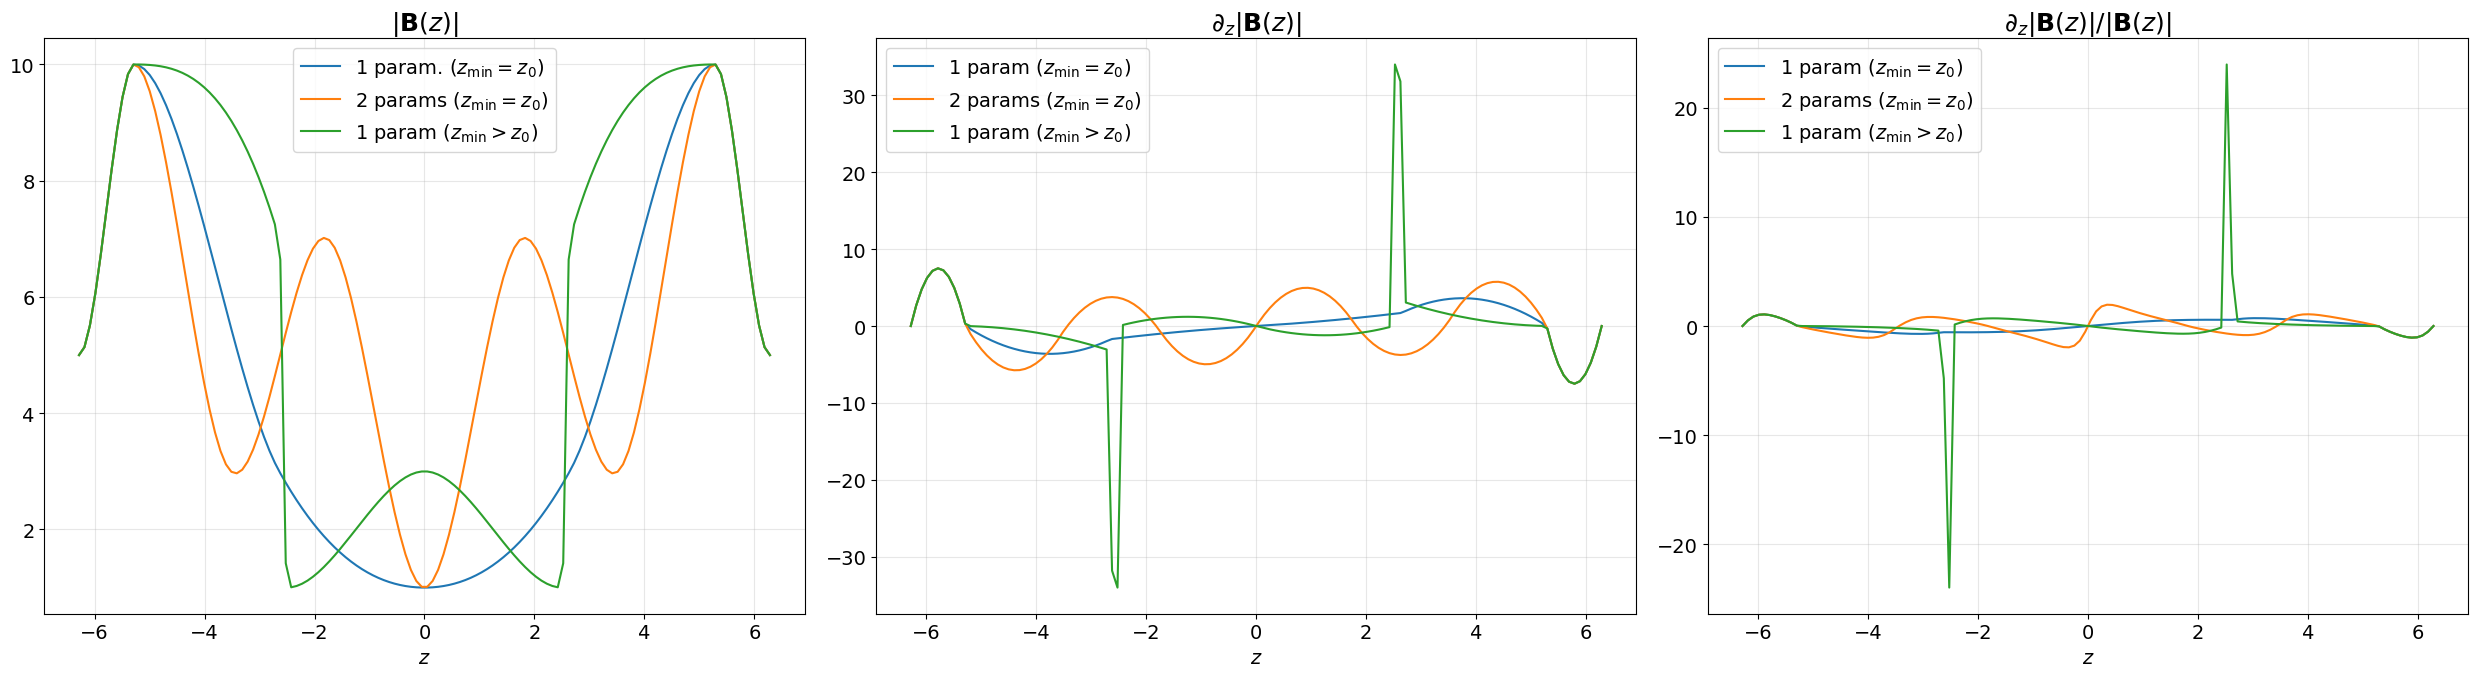

In [3]:
zs = jnp.linspace(-LZ, LZ, nz, endpoint=True)
z_max = LZ - 1.0


# 1 parameter spline (case when z_min = z_0)
z_min_0 = 0.0
B_0_0 = B_min # has to be equal to B_min since z_0 = z_min
B0, dB0 = build_B(B_min, B_max, z_min_0, z_max, LZ,
                     B_b=B_b, z_0=0.0)
dB0_v = jax.vmap(dB0, in_axes=(None,0))



## Parameter selections, must include B_0 value and be between B_min and B_max
params_0 = jnp.array([B_0_0, 3.0])
B0_eval = B0(params_0, zs)
dB0_eval = dB0_v(params_0, zs)
g0 = lambda z: dB0_v(params_0, z) / B0(params_0, z)
g0_eval = g0(zs)
B_max0 = jnp.max(B0(params_0, zs))
print("B_max0:", B_max0)
B_min0 = jnp.min(B0(params_0, zs))
print("B_min0:", B_min0)
mu_max0 = -jnp.log(1e-12)/(B_max0)
mirror_ratio_0 = B_max0/B_min0
print("Mirror ratio (B_max/B_min): {:.3f}".format(mirror_ratio_0))
print("mu_0: {:.7f}".format(mu_max0))


# 2 parameters spline (case when z_min = z_0)
z_min_1 = 0.0
B_0_1 = B_min # has to be equal to B_min since z_0 = z_min
B1, dB1 = build_B(B_min, B_max, z_min_1, z_max, LZ,
                     B_b=B_b, z_0=0.0)
dB1_v = jax.vmap(dB1, in_axes=(None,0))

## Parameter selections, must include B_0 value and be between B_min and B_max
params_1 = jnp.array([B_0_1, 7.0, 3.0])
B1_eval = B1(params_1, zs)
dB1_eval = dB1_v(params_1, zs)
g1 = lambda z: dB1_v(params_1, z) / B1(params_1, z)
g1_eval = g1(zs)
B_max1 = jnp.max(B1(params_1, zs))
print("B_max1:", B_max1)
B_min1 = jnp.min(B1(params_1, zs))
print("B_min1:", B_min1)
mu_max1 = -jnp.log(1e-12)/(B_max1)
mirror_ratio_1 = B_max1/B_min1
print("Mirror ratio (B_max/B_min): {:.3f}".format(mirror_ratio_1))
print("mu_0: {:.7f}".format(mu_max1))


# 1 parameter spline (case when z_min > z_0)
z_min = 2.5
B_0_2 = 3.0  # Can be chosen between B_min and B_max
B2, dB2 = build_B(B_min, B_max, z_min, z_max, LZ,
                     B_b=B_b, z_0=0.0)
dB2_v = jax.vmap(dB2, in_axes=(None,0))

## Parameter selections, must include B_0 value and be between B_min and B_max
params_2 = jnp.array([B_0_2, 7.0])
B2_eval = B2(params_2, zs)
dB2_eval = dB2_v(params_2, zs)
g2 = lambda z: dB2_v(params_2, z) / B2(params_2, z)
g2_eval = g2(zs)
B_max2 = jnp.max(B2(params_2, zs))
print("B_max2:", B_max2)
B_min2 = jnp.min(B2(params_2, zs))
print("B_min2:", B_min2)
mu_max2 = -jnp.log(1e-12)/(B_max2)
mirror_ratio_2 = B_max2/B_min2
print("Mirror ratio (B_max/B_min): {:.3f}".format(mirror_ratio_2))
print("mu_0: {:.7f}".format(mu_max2))


# Plot
fig, axs = plt.subplots(1,3, figsize=(25,7))

# Main plot
axs[0].plot(zs, B0(params_0, zs), label='1 param. ($z_\\min = z_0$)')
axs[0].plot(zs, B1(params_1, zs), label='2 params ($z_\\min = z_0$)')
axs[0].plot(zs, B2(params_2, zs), label='1 param ($z_\\min > z_0$)')
#axs[0].axvline(spline_0.z_max, color='r', linestyle='--', alpha=0.5)
#axs[0].axvline(-spline_0.z_max, color='r', linestyle='--', alpha=0.5)
axs[0].set_xlabel('$z$', fontsize=14)
axs[0].set_title('$|\\mathbf{B}(z)|$')
axs[0].legend()
axs[0].grid(True, alpha=0.3)


axs[1].plot(zs, dB0(params_0, zs), label='1 param ($z_\\min = z_0$)')
axs[1].plot(zs, dB1(params_1, zs), label='2 params ($z_\\min = z_0$)')
axs[1].plot(zs, dB2(params_2, zs), label='1 param ($z_\\min > z_0$)')
axs[1].set_xlabel('$z$', fontsize=14)
axs[1].set_title('$\\partial_z |\\mathbf{B}(z)|$')
axs[1].legend()
axs[1].grid(True, alpha=0.3)


axs[2].plot(zs, g0(zs), label='1 param ($z_\\min = z_0$)')
axs[2].plot(zs, g1(zs), label='2 params ($z_\\min = z_0$)')
axs[2].plot(zs, g2(zs), label='1 param ($z_\\min > z_0$)')
axs[2].set_xlabel('$z$', fontsize=14)
axs[2].set_title('$\\partial_z |\\mathbf{B}(z)| / |\\mathbf{B}(z)|$')
axs[2].legend()
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
LMU = max(mu_max0, mu_max1, mu_max2)
mesh = make_mesh(LZ, LV, LMU, nz, nv, nmu)


### 1 parameter (z_min = z_0)
B_norm = B0(params_0, mesh.Z)

f_eq0 = jnp.exp(-0.5*((mesh.V)**2 + 2*B_norm*mesh.MU)) #/ B_norm

sigma_z = 1.0
f_eq_Z = 0.1 + jnp.exp(-mesh.Z**2/(2*sigma_z**2))

f_iv0 = f_eq_Z * f_eq0

C = 1 / (jnp.sum((jnp.sum(f_iv0, axis=(1,2))*mesh.dv*mesh.dmu))*mesh.dz)

f_iv0 = C * f_iv0

### 2 parameters (z_min = z_0)
B_norm = B1(params_1, mesh.Z)

f_eq1 = jnp.exp(-0.5*((mesh.V)**2 + 2*B_norm*mesh.MU)) #/ B_norm

sigma_z = 1.0
f_eq_Z = 0.1 + jnp.exp(-mesh.Z**2/(2*sigma_z**2))

f_iv1 = f_eq_Z * f_eq1

C = 1 / (jnp.sum((jnp.sum(f_iv1, axis=(1,2))*mesh.dv*mesh.dmu))*mesh.dz)

f_iv1 = C * f_iv1

### 1 parameter (z_min > z_0)
B_norm = B2(params_2, mesh.Z)

f_eq2 = jnp.exp(-0.5*((mesh.V)**2 + 2*B_norm*mesh.MU)) #/ B_norm

sigma_z = 1.0
f_eq_Z = 0.1 + jnp.exp(-mesh.Z**2/(2*sigma_z**2))

f_iv2 = f_eq_Z * f_eq2

C = 1 / (jnp.sum((jnp.sum(f_iv2, axis=(1,2))*mesh.dv*mesh.dmu))*mesh.dz)

f_iv2 = C * f_iv2

In [5]:
all_data_l = jnp.concatenate([
    f_iv0[:,:,0].ravel(),
    f_iv1[:,:,0].ravel(),
    f_iv2[:,:,0].ravel(),
])

vmin_l = all_data_l.min()
vmax_l = all_data_l.max()

norm_l = colors.Normalize(vmin=vmin_l, vmax=vmax_l)

all_data_c = jnp.concatenate([
    f_iv0[:,:,int(mesh.nmu/2)].ravel(),
    f_iv1[:,:,int(mesh.nmu/2)].ravel(),
    f_iv2[:,:,int(mesh.nmu/2)].ravel(),
])

vmin_c = all_data_c.min()
vmax_c = all_data_c.max()

norm_c = colors.Normalize(vmin=vmin_c, vmax=vmax_c)

all_data_r = jnp.concatenate([
    f_iv0[:,:,-1].ravel(),
    f_iv1[:,:,-1].ravel(),
    f_iv2[:,:,-1].ravel(),
])

vmin_r = all_data_r.min()
vmax_r = all_data_r.max()

norm_r = colors.Normalize(vmin=vmin_r, vmax=vmax_r)

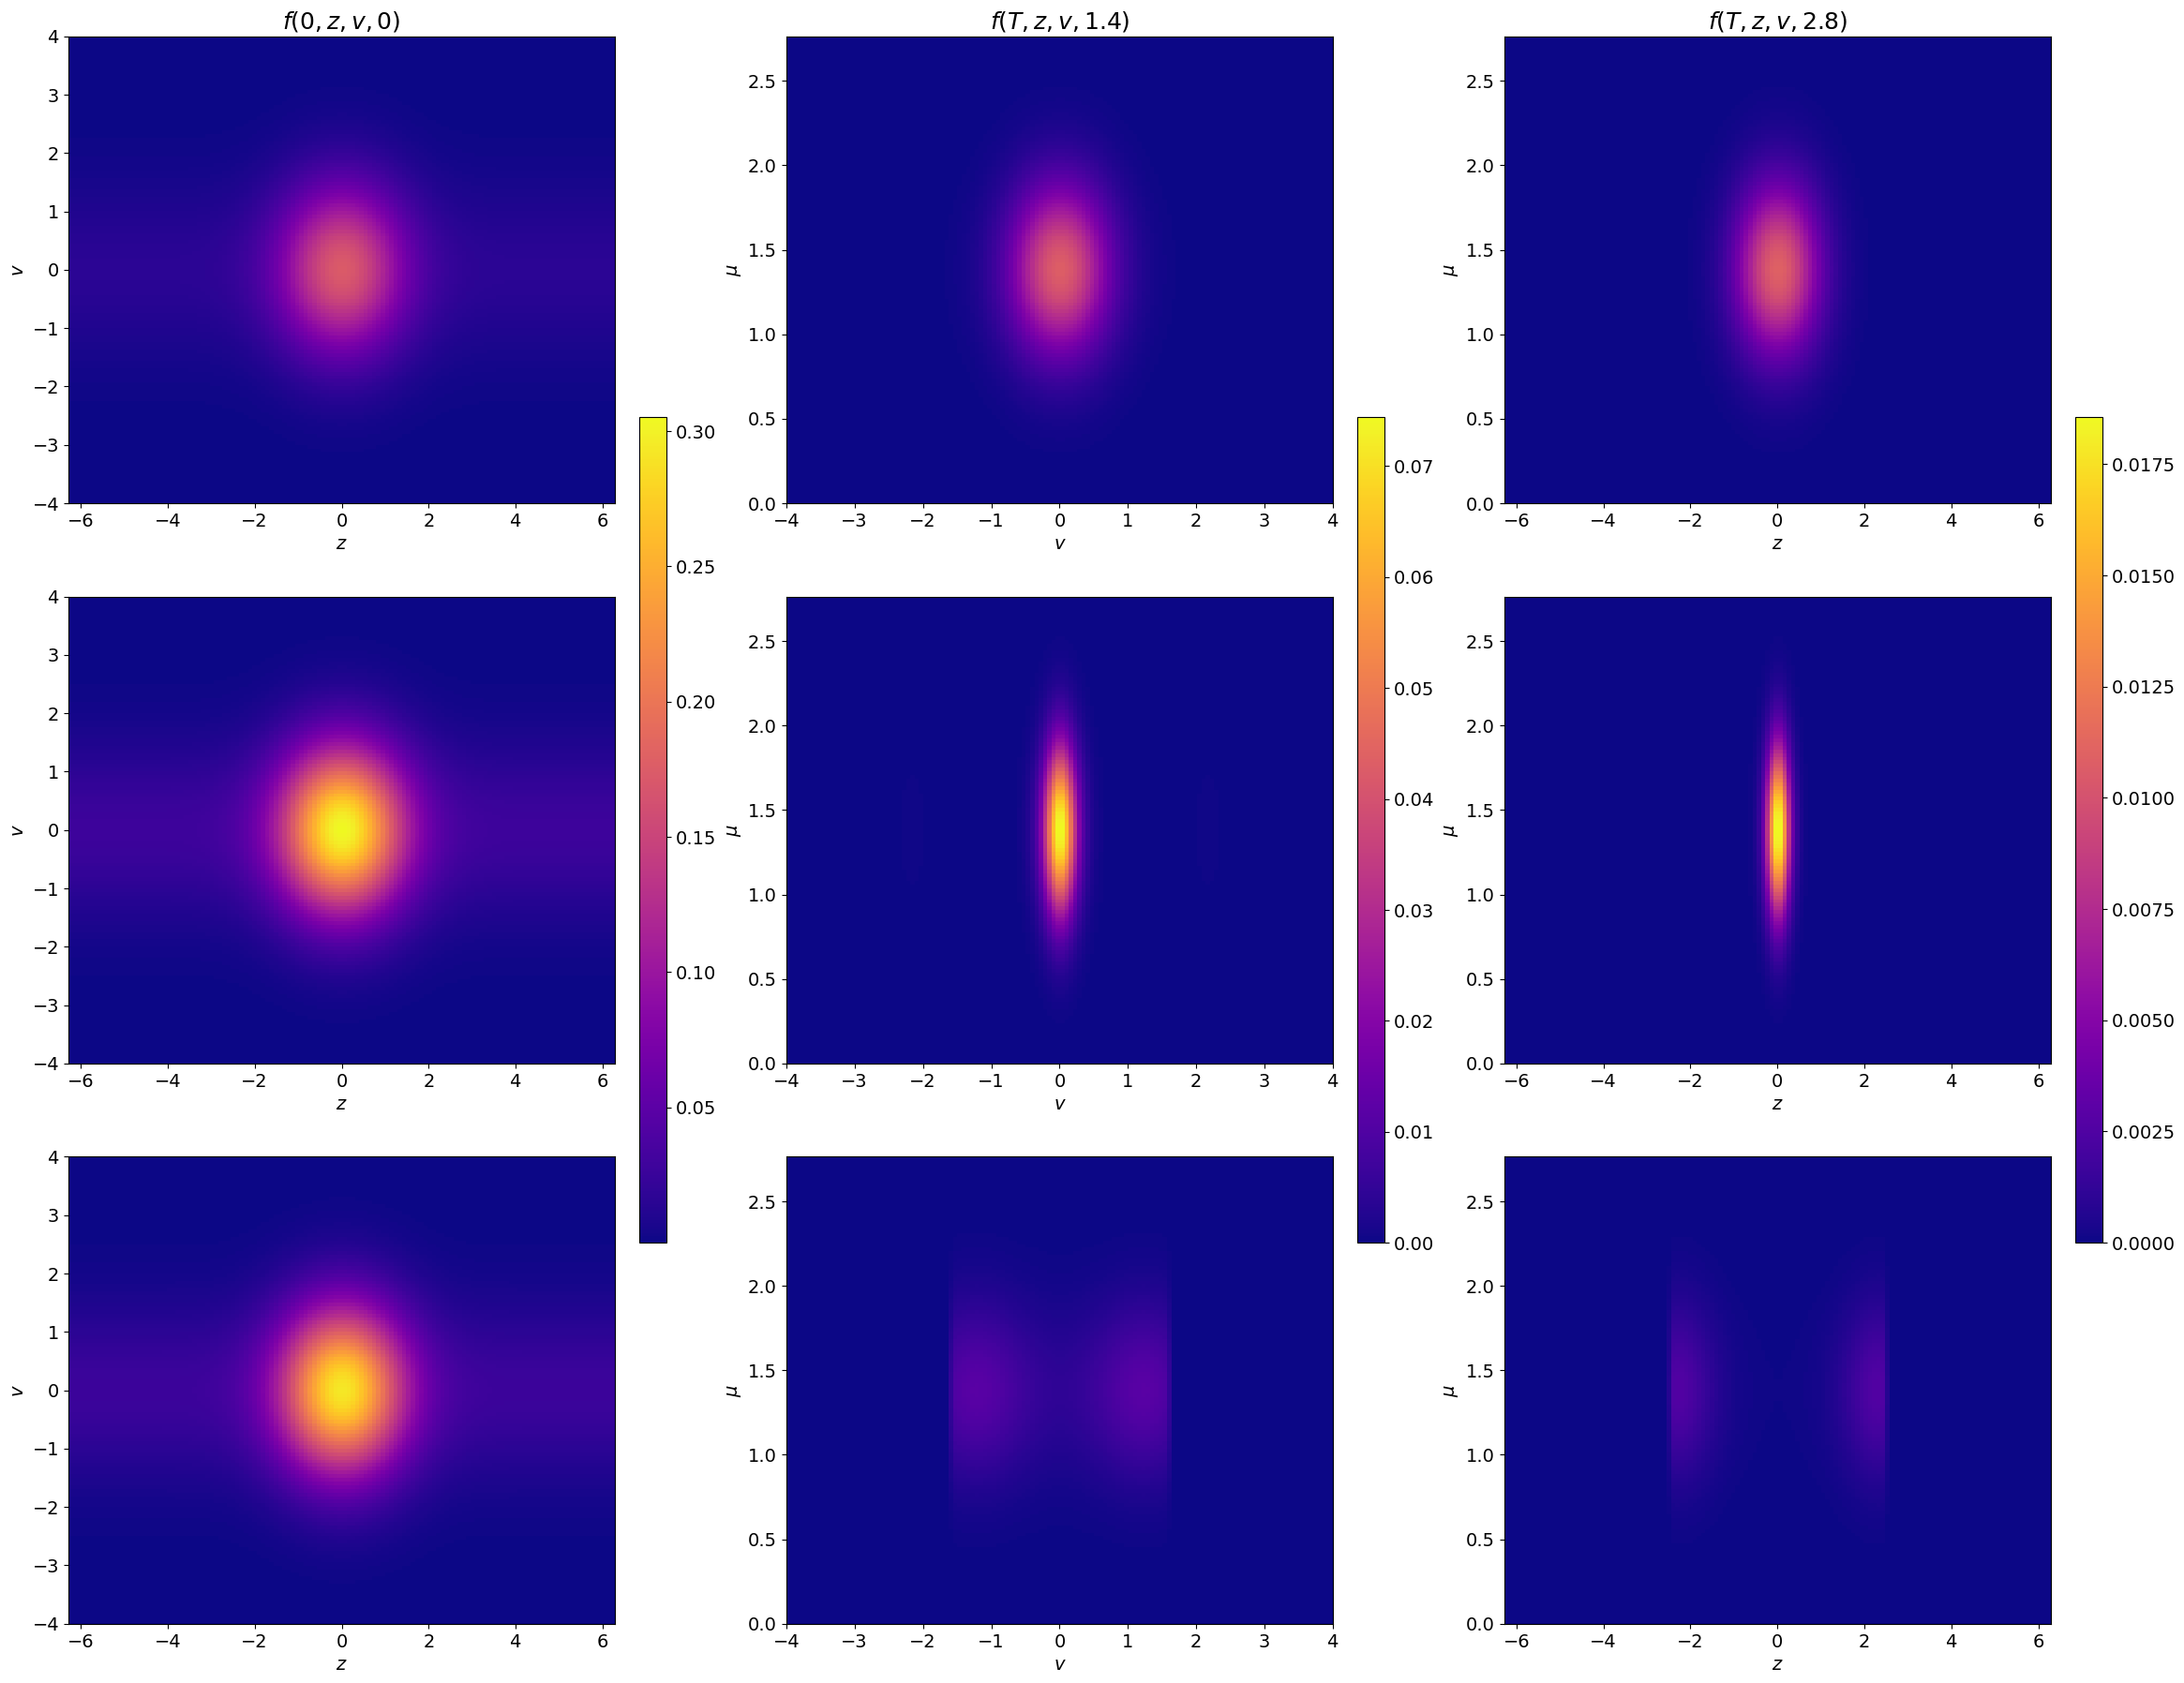

In [6]:
fig, axs = plt.subplots(3,3 ,figsize=(28, 22))

im_l = axs[0,0].imshow(f_iv0[:,:,0].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma', norm=norm_l)
axs[0,0].set_xlabel("$z$")
axs[0,0].set_ylabel("$v$")
axs[0,0].set_title("$f(0,z,v,0)$")
#fig.colorbar(im, ax=axs[0,0], fraction=0.046, pad=0.04)

im_c = axs[0,1].imshow(f_iv0[:,:,int(mesh.nmu/2)].T, origin="lower", extent=[mesh.vs[0], mesh.vs[-1], mesh.mus[0], mesh.mus[-1]],
                   aspect='auto', cmap='plasma', norm=norm_c)
axs[0,1].set_xlabel("$v$")
axs[0,1].set_ylabel("$\\mu$")
axs[0,1].set_title("$f(T,z,v,{:.1f})$".format(mesh.mus[int(mesh.nmu/2)]))
#fig.colorbar(im, ax=axs[0,1], fraction=0.046, pad=0.04)

im_r = axs[0,2].imshow(f_iv0[:,:,-1].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.mus[0], mesh.mus[-1]],
                   aspect='auto', cmap='plasma', norm=norm_r)
axs[0,2].set_xlabel("$z$")
axs[0,2].set_ylabel("$\\mu$")
axs[0,2].set_title("$f(T,z,v,{:.1f})$".format(mesh.mus[-1]))
#fig.colorbar(im, ax=axs[0,2], fraction=0.046, pad=0.04)


im_l = axs[1,0].imshow(f_iv1[:,:,0].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma', norm=norm_l)
axs[1,0].set_xlabel("$z$")
axs[1,0].set_ylabel("$v$")
#axs[1,0].set_title("$f(0,z,v,0)$")
#fig.colorbar(im, ax=axs[1,0], fraction=0.046, pad=0.04)

im_c = axs[1,1].imshow(f_iv1[:,:,int(mesh.nmu/2)].T, origin="lower", extent=[mesh.vs[0], mesh.vs[-1], mesh.mus[0], mesh.mus[-1]],
                   aspect='auto', cmap='plasma', norm=norm_c)
axs[1,1].set_xlabel("$v$")
axs[1,1].set_ylabel("$\\mu$")
#axs[1,1].set_title("$f(T,z,v,{:.1f})$".format(mesh.mus[int(mesh.nmu/2)]))
#fig.colorbar(im, ax=axs[1,1], fraction=0.046, pad=0.04)

im_r = axs[1,2].imshow(f_iv1[:,:,-1].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.mus[0], mesh.mus[-1]],
                   aspect='auto', cmap='plasma', norm=norm_r)
axs[1,2].set_xlabel("$z$")
axs[1,2].set_ylabel("$\\mu$")
#axs[1,2].set_title("$f(T,z,v,{:.1f})$".format(mesh.mus[-1]))
#fig.colorbar(im, ax=axs[1,2], fraction=0.046, pad=0.04)


im_l = axs[2,0].imshow(f_iv2[:,:,0].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma', norm=norm_l)
axs[2,0].set_xlabel("$z$")
axs[2,0].set_ylabel("$v$")
#axs[2,0].set_title("$f(0,z,v,0)$")
#fig.colorbar(im, ax=axs[2,0], fraction=0.046, pad=0.04)

im_c = axs[2,1].imshow(f_iv2[:,:,int(mesh.nmu/2)].T, origin="lower", extent=[mesh.vs[0], mesh.vs[-1], mesh.mus[0], mesh.mus[-1]],
                   aspect='auto', cmap='plasma', norm=norm_c)
axs[2,1].set_xlabel("$v$")
axs[2,1].set_ylabel("$\\mu$")
#axs[2,1].set_title("$f(T,z,v,{:.1f})$".format(mesh.mus[int(mesh.nmu/2)]))
#fig.colorbar(im, ax=axs[2,1], fraction=0.046, pad=0.04)

im_r = axs[2,2].imshow(f_iv2[:,:,-1].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.mus[0], mesh.mus[-1]],
                   aspect='auto', cmap='plasma', norm=norm_r)
axs[2,2].set_xlabel("$z$")
axs[2,2].set_ylabel("$\\mu$")
#axs[2,2].set_title("$f(T,z,v,{:.1f})$".format(mesh.mus[-1]))
#fig.colorbar(im, ax=axs[2,2], fraction=0.046, pad=0.04)


fig.colorbar(im_l, ax=axs[:,0], shrink=0.75, fraction=0.046, pad=0.04, aspect=30)
fig.colorbar(im_c, ax=axs[:,1], shrink=0.75, fraction=0.046, pad=0.04, aspect=30)
fig.colorbar(im_r, ax=axs[:,2], shrink=0.75, fraction=0.046, pad=0.04, aspect=30)

plt.show()
#plt.savefig('Mirror/Plots/splines/initial_density.png', dpi=300, transparent=True, bbox_inches="tight")

In [7]:
solver = VlasovPoissonSolver(mesh=mesh, dt=dt)

# JIT-compiled forward solver
solver_jit = jax.jit(solver.run_forward_jax_scan, static_argnames=('t_final',))

In [9]:
f_array_0, f_total_0, E_array_0, ee_array_0, rho_array_0 = solver_jit(f_iv0, B0_eval, dB0_eval, g0_eval, t_final=t_final)
rho_array_0 = jnp.vstack([jnp.sum(f_iv0, axis=(1,2))*mesh.dv*mesh.dmu, rho_array_0])
f_array_1, f_total_1, E_array_1, ee_array_1, rho_array_1 = solver_jit(f_iv1, B1_eval, dB1_eval, g1_eval, t_final=t_final)
rho_array_1 = jnp.vstack([jnp.sum(f_iv1, axis=(1,2))*mesh.dv*mesh.dmu, rho_array_1])
f_array_2, f_total_2, E_array_2, ee_array_2, rho_array_2 = solver_jit(f_iv2, B2_eval, dB2_eval, g2_eval, t_final=t_final)
rho_array_2 = jnp.vstack([jnp.sum(f_iv2, axis=(1,2))*mesh.dv*mesh.dmu, rho_array_2])

In [10]:
all_data_l = jnp.concatenate([
    f_array_0[:,:,0].ravel(),
    f_array_1[:,:,0].ravel(),
    f_array_2[:,:,0].ravel(),
])

vmin_l = all_data_l.min()
vmax_l = all_data_l.max()

norm_l = colors.Normalize(vmin=vmin_l, vmax=vmax_l)

all_data_c = jnp.concatenate([
    f_array_0[:,:,int(mesh.nmu/2)].ravel(),
    f_array_1[:,:,int(mesh.nmu/2)].ravel(),
    f_array_2[:,:,int(mesh.nmu/2)].ravel(),
])

vmin_c = all_data_c.min()
vmax_c = all_data_c.max()

norm_c = colors.Normalize(vmin=vmin_c, vmax=vmax_c)

all_data_r = jnp.concatenate([
    f_array_0[:,:,-1].ravel(),
    f_array_1[:,:,-1].ravel(),
    f_array_2[:,:,-1].ravel(),
])

vmin_r = all_data_r.min()
vmax_r = all_data_r.max()

norm_r = colors.Normalize(vmin=vmin_r, vmax=vmax_r)

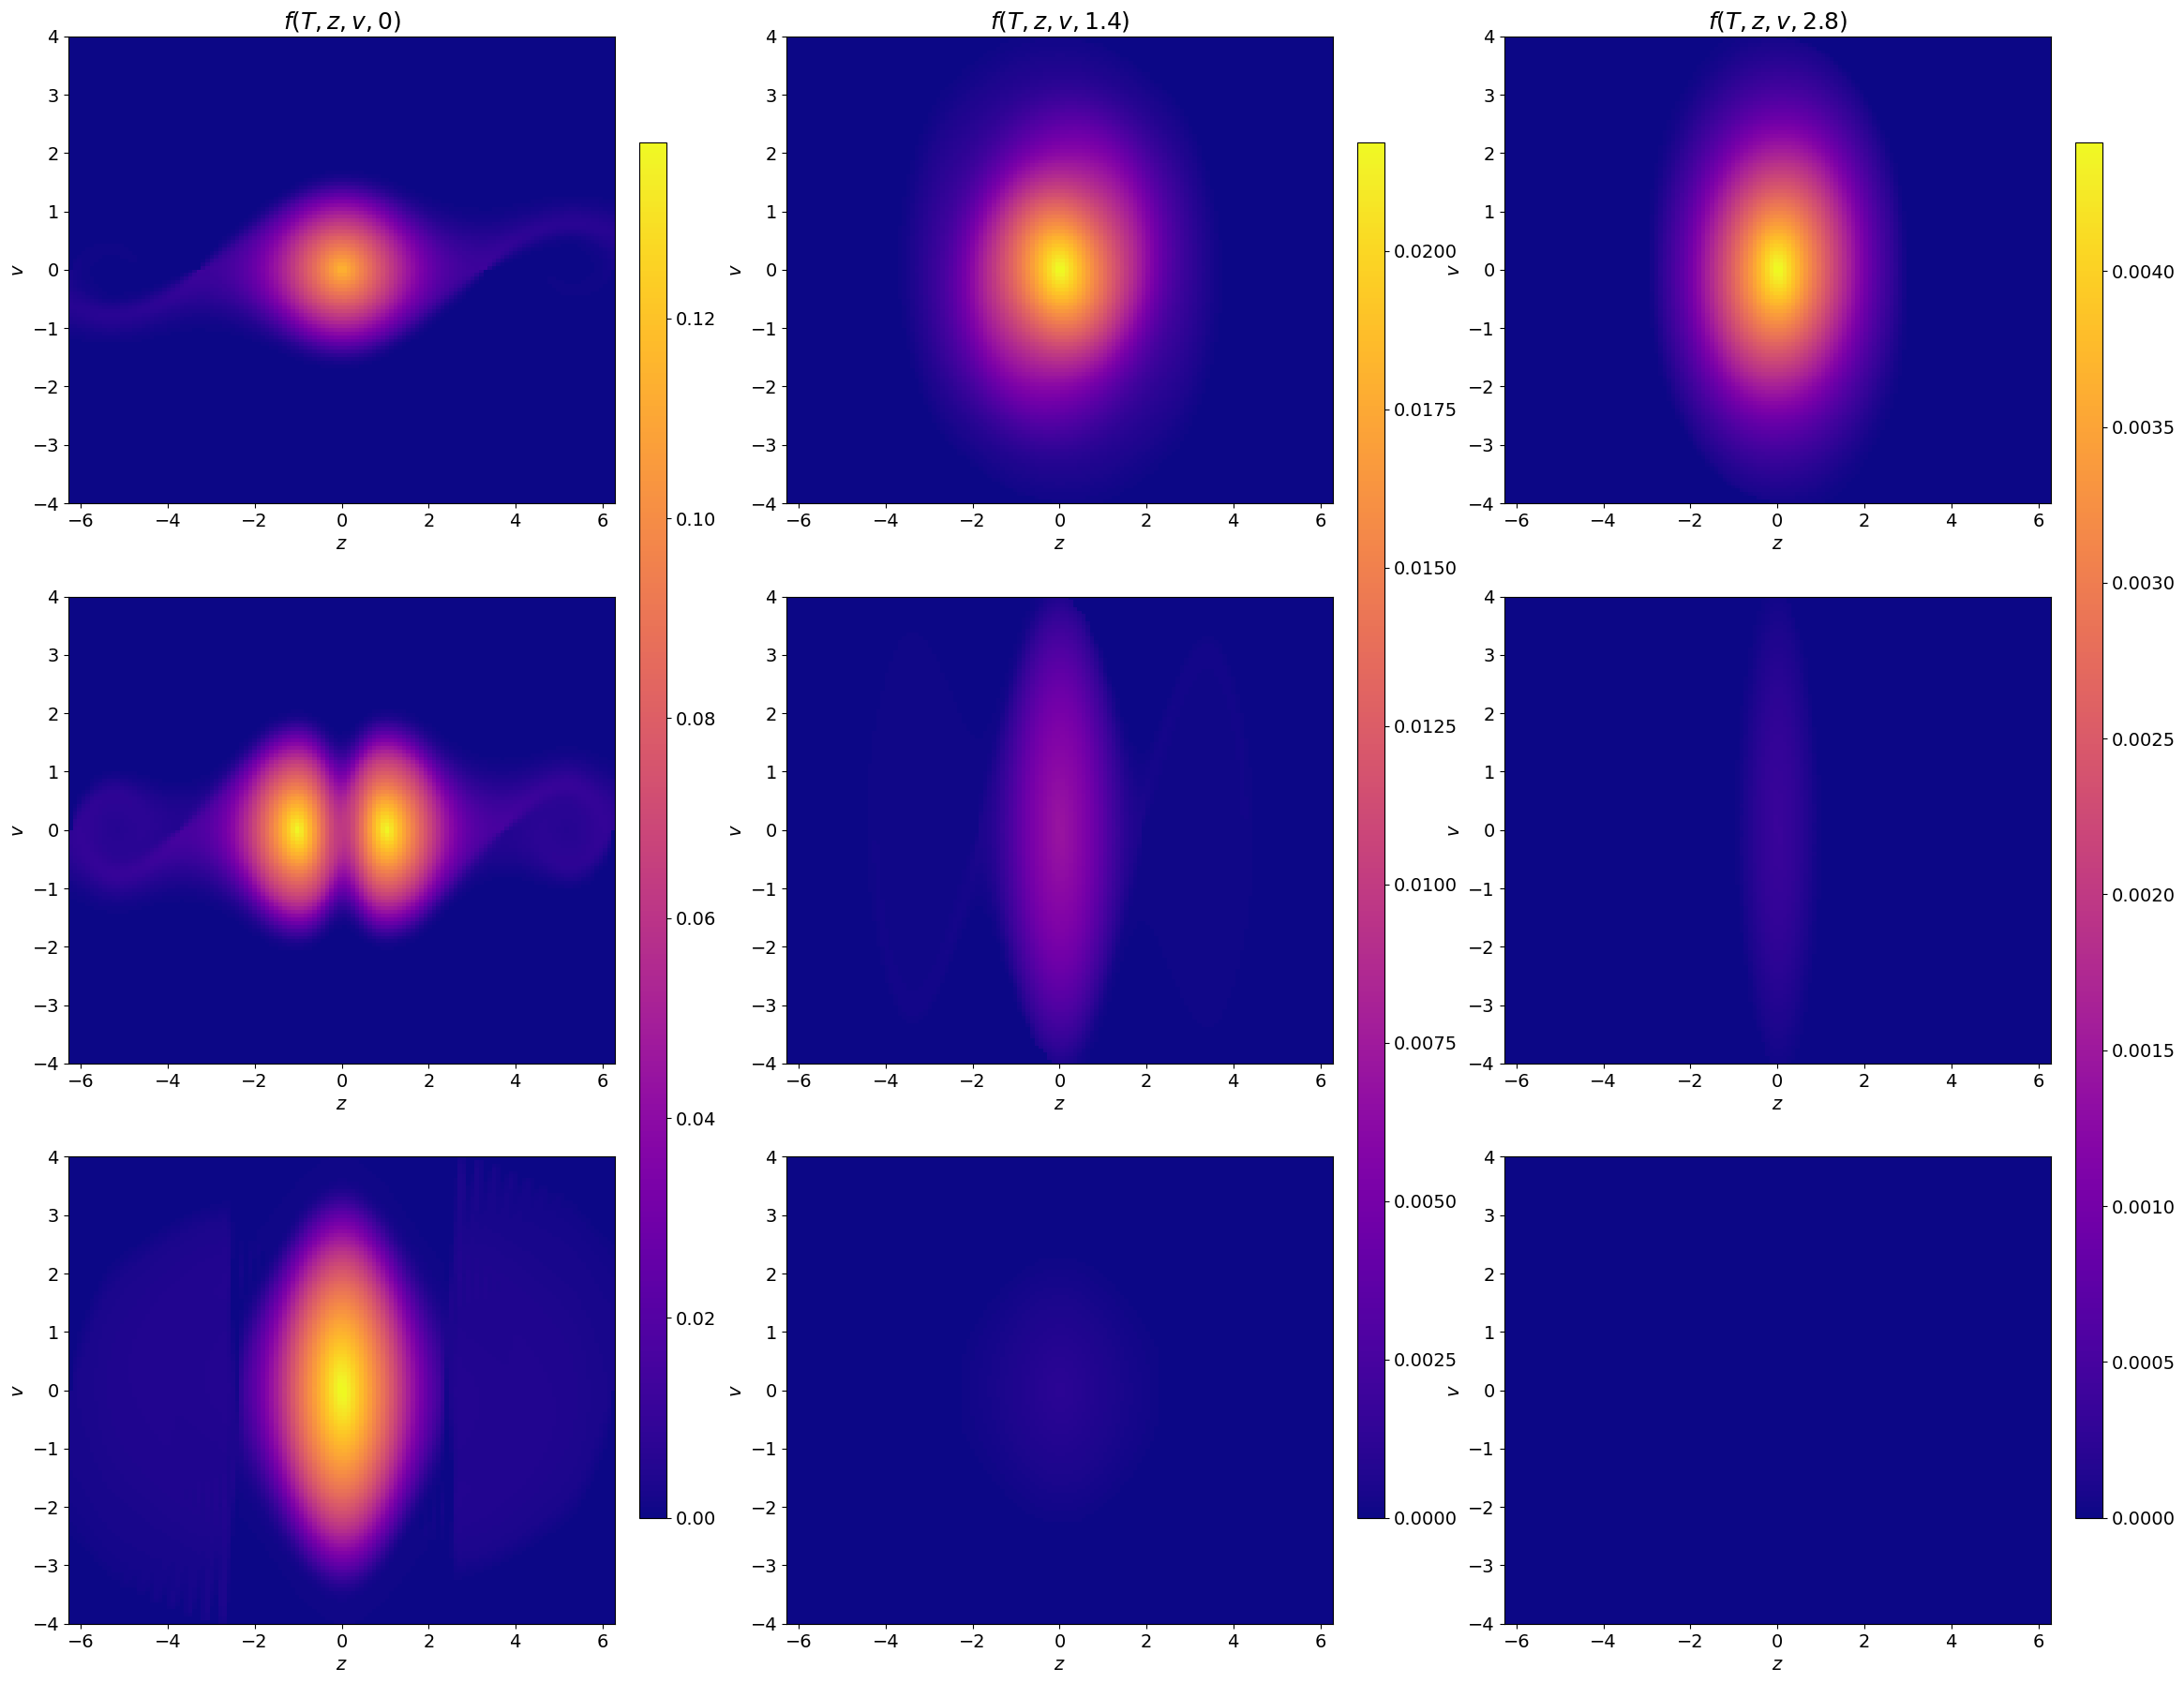

In [11]:
fig, axs = plt.subplots(3,3 ,figsize=(28, 22))

im_l = axs[0,0].imshow(f_array_0[:,:,0].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma', norm=norm_l)
axs[0,0].set_xlabel("$z$")
axs[0,0].set_ylabel("$v$")
axs[0,0].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[0]))
#fig.colorbar(im, ax=axs[0,0], fraction=0.046, pad=0.04)

im_c = axs[0,1].imshow(f_array_0[:,:,int(mesh.nmu/2)].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma', norm=norm_c)
axs[0,1].set_xlabel("$z$")
axs[0,1].set_ylabel("$v$")
axs[0,1].set_title("$f(T,z,v,{:.1f})$".format(mesh.mus[int(mesh.nmu/2)]))
#fig.colorbar(im, ax=axs[0,1], fraction=0.046, pad=0.04)

im_r = axs[0,2].imshow(f_array_0[:,:,-1].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma', norm=norm_r)
axs[0,2].set_xlabel("$z$")
axs[0,2].set_ylabel("$v$")
axs[0,2].set_title("$f(T,z,v,{:.1f})$".format(mesh.mus[-1]))
#fig.colorbar(im, ax=axs[0,2], fraction=0.046, pad=0.04)


im_l = axs[1,0].imshow(f_array_1[:,:,0].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma', norm=norm_l)
axs[1,0].set_xlabel("$z$")
axs[1,0].set_ylabel("$v$")
#axs[1,0].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[0]))
#fig.colorbar(im, ax=axs[1,0], fraction=0.046, pad=0.04)

im_c = axs[1,1].imshow(f_array_1[:,:,int(mesh.nmu/2)].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma', norm=norm_c)
axs[1,1].set_xlabel("$z$")
axs[1,1].set_ylabel("$v$")
#axs[1,1].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[int(mesh.nmu/2)]))
#fig.colorbar(im, ax=axs[1,1], fraction=0.046, pad=0.04)

im_r = axs[1,2].imshow(f_array_1[:,:,-1].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma', norm=norm_r)
axs[1,2].set_xlabel("$z$")
axs[1,2].set_ylabel("$v$")
#axs[1,2].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[-1]))
#fig.colorbar(im, ax=axs[1,2], fraction=0.046, pad=0.04)


im_l = axs[2,0].imshow(f_array_2[:,:,0].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma', norm=norm_l)
axs[2,0].set_xlabel("$z$")
axs[2,0].set_ylabel("$v$")
#axs[2,0].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[0]))
#fig.colorbar(im, ax=axs[2,0], fraction=0.046, pad=0.04)

im_c = axs[2,1].imshow(f_total_2[-1,:,:,int(mesh.nmu/2)].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma', norm=norm_c)
axs[2,1].set_xlabel("$z$")
axs[2,1].set_ylabel("$v$")
#axs[2,1].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[int(mesh.nmu/2)]))
#fig.colorbar(im, ax=axs[2,1], fraction=0.046, pad=0.04)

im_r = axs[2,2].imshow(f_array_2[:,:,-1].T, origin="lower", extent=[mesh.zs[0], mesh.zs[-1], mesh.vs[0], mesh.vs[-1]],
                   aspect='auto', cmap='plasma', norm=norm_r)
axs[2,2].set_xlabel("$z$")
axs[2,2].set_ylabel("$v$")
#axs[2,2].set_title("$f(T,z,v,{:.0f})$".format(mesh.mus[-1]))
#fig.colorbar(im, ax=axs[2,2], fraction=0.046, pad=0.04)

fig.colorbar(im_l, ax=axs[:,0], shrink=1.0, fraction=0.046, pad=0.04, aspect=50)
fig.colorbar(im_c, ax=axs[:,1], shrink=1.0, fraction=0.046, pad=0.04, aspect=50)
fig.colorbar(im_r, ax=axs[:,2], shrink=1.0, fraction=0.046, pad=0.04, aspect=50)

plt.show()
#plt.savefig('Mirror/Plots/splines/final_density.png', dpi=300, transparent=True, bbox_inches="tight")

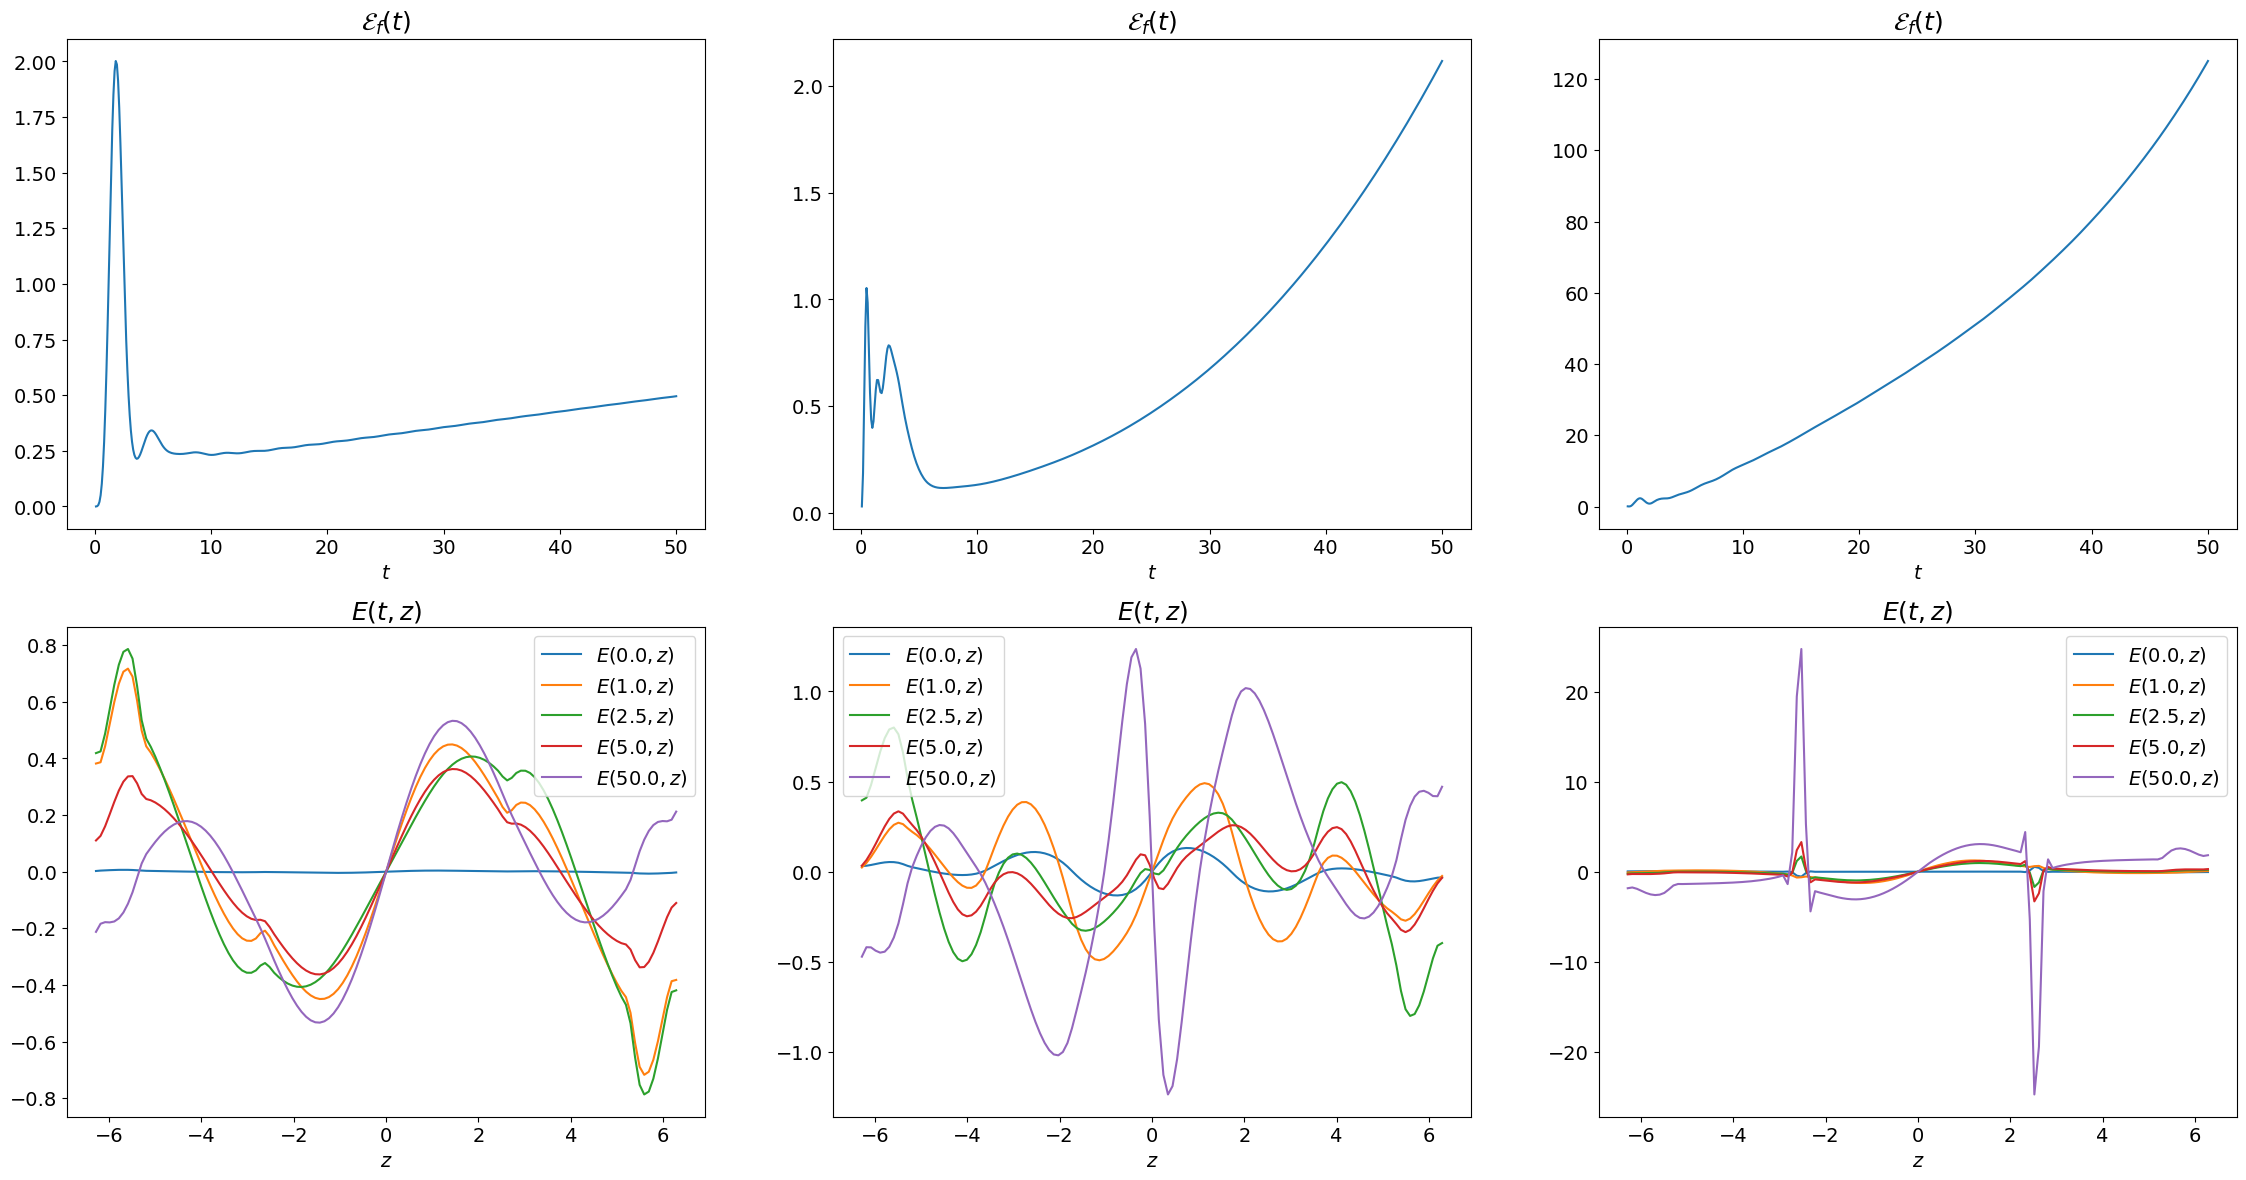

In [12]:
fig, axs = plt.subplots(2,3 ,figsize=(28, 14))

axs[0,0].plot(t_values[1:], ee_array_0)
axs[0,0].set_title("$\\mathcal{E}_{f}(t)$")
#axs[0,0].set_yscale('log')
axs[0,0].set_xlabel("$t$")

axs[1,0].plot(mesh.zs, E_array_0[0,:], label='$E({:.1f},z)$'.format(t_values[0]))
axs[1,0].plot(mesh.zs, E_array_0[10,:], label='$E({:.1f},z)$'.format(t_values[10]))
axs[1,0].plot(mesh.zs, E_array_0[25,:], label='$E({:.1f},z)$'.format(t_values[25]))
axs[1,0].plot(mesh.zs, E_array_0[50,:], label='$E({:.1f},z)$'.format(t_values[50]))
#axs[1,0].plot(mesh.zs, E_array_0[300,:], label='$E({:.1f},z)$'.format(t_values[300]))
#axs[1,0].plot(mesh.zs, E_array_0[400,:], label='$E({:.1f},z)$'.format(t_values[400]))
axs[1,0].plot(mesh.zs, E_array_0[-1,:], label='$E({:.1f},z)$'.format(t_values[-1]))
#axs[1,0].set_yscale('symlog')
axs[1,0].set_title("$E(t,z)$")
axs[1,0].set_xlabel("$z$")
axs[1,0].legend()


axs[0,1].plot(t_values[1:], ee_array_1)
axs[0,1].set_title("$\\mathcal{E}_{f}(t)$")
#axs[0,1].set_yscale('log')
axs[0,1].set_xlabel("$t$")

axs[1,1].plot(mesh.zs, E_array_1[0,:], label='$E({:.1f},z)$'.format(t_values[0]))
axs[1,1].plot(mesh.zs, E_array_1[10,:], label='$E({:.1f},z)$'.format(t_values[10]))
axs[1,1].plot(mesh.zs, E_array_1[25,:], label='$E({:.1f},z)$'.format(t_values[25]))
axs[1,1].plot(mesh.zs, E_array_1[50,:], label='$E({:.1f},z)$'.format(t_values[50]))
#axs[1,1].plot(mesh.zs, E_array_1[300,:], label='$E({:.1f},z)$'.format(t_values[300]))
#axs[1,1].plot(mesh.zs, E_array_1[400,:], label='$E({:.1f},z)$'.format(t_values[400]))
axs[1,1].plot(mesh.zs, E_array_1[-1,:], label='$E({:.1f},z)$'.format(t_values[-1]))
#axs[1,1].set_yscale('symlog')
axs[1,1].set_title("$E(t,z)$")
axs[1,1].set_xlabel("$z$")
axs[1,1].legend()




axs[0,2].plot(t_values[1:], ee_array_2)
axs[0,2].set_title("$\\mathcal{E}_{f}(t)$")
#axs[0,2].set_yscale('log')
axs[0,2].set_xlabel("$t$")

axs[1,2].plot(mesh.zs, E_array_2[0,:], label='$E({:.1f},z)$'.format(t_values[0]))
axs[1,2].plot(mesh.zs, E_array_2[10,:], label='$E({:.1f},z)$'.format(t_values[10]))
axs[1,2].plot(mesh.zs, E_array_2[25,:], label='$E({:.1f},z)$'.format(t_values[25]))
axs[1,2].plot(mesh.zs, E_array_2[50,:], label='$E({:.1f},z)$'.format(t_values[50]))
#axs[1,2].plot(mesh.zs, E_array_2[300,:], label='$E({:.1f},z)$'.format(t_values[300]))
#axs[1,2].plot(mesh.zs, E_array_2[400,:], label='$E({:.1f},z)$'.format(t_values[400]))
axs[1,2].plot(mesh.zs, E_array_2[-1,:], label='$E({:.1f},z)$'.format(t_values[-1]))
#axs[1,2].set_yscale('symlog')
axs[1,2].set_title("$E(t,z)$")
axs[1,2].set_xlabel("$z$")
axs[1,2].legend()



plt.show()
#plt.savefig('Mirror/Plots/splines/electric_energies.png', dpi=300, transparent=True, bbox_inches="tight")

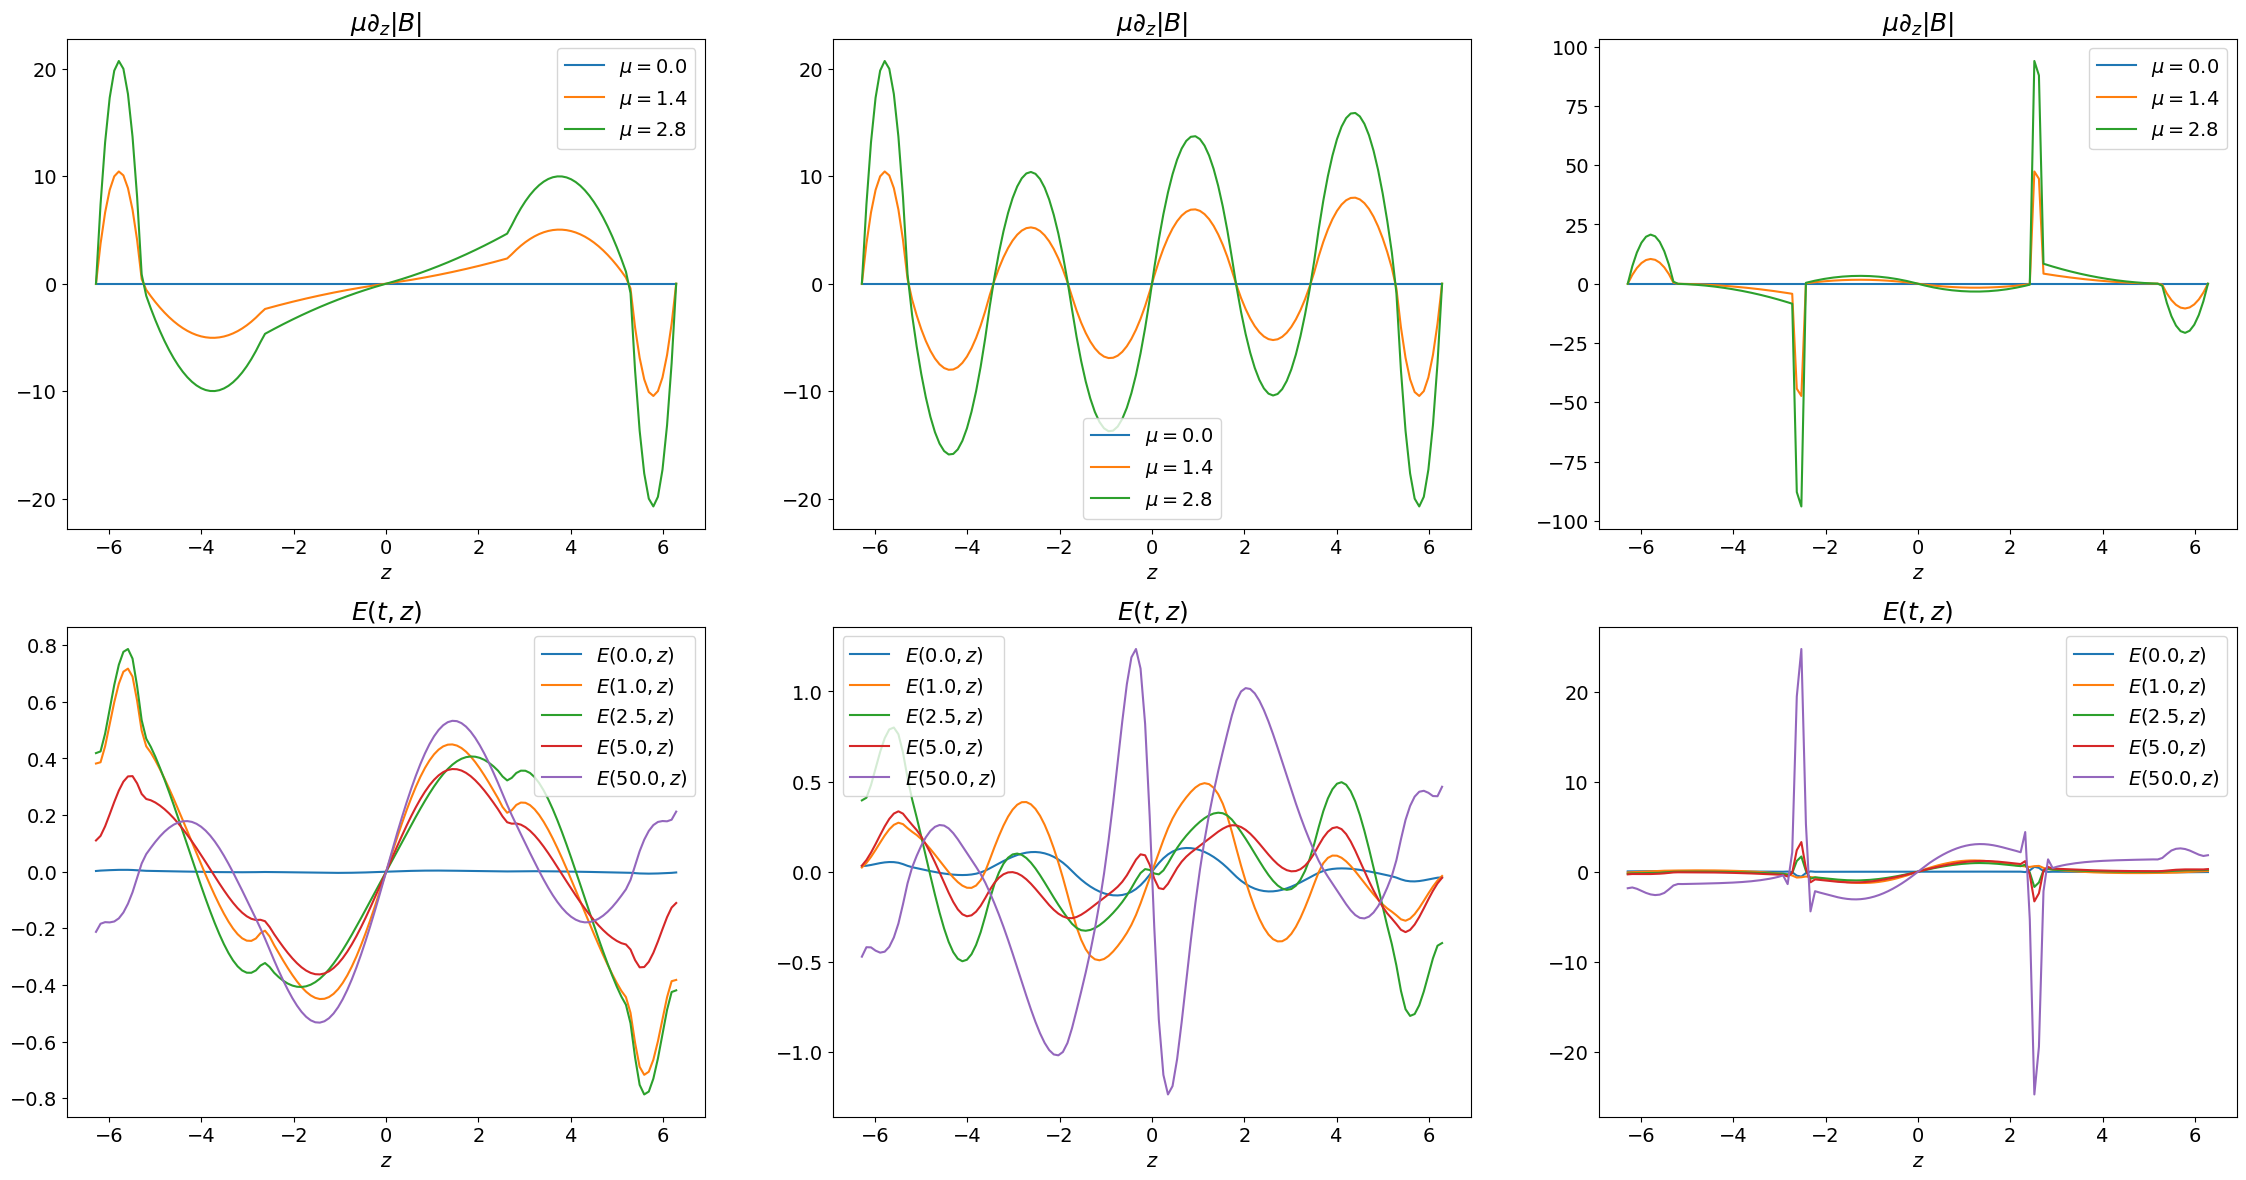

In [13]:
fig, axs = plt.subplots(2,3 ,figsize=(28, 14))

axs[0,0].plot(mesh.zs, mesh.mus[0]*dB0_eval, label='$\\mu={:.1f}$'.format(mesh.mus[0]))
axs[0,0].plot(mesh.zs, mesh.mus[int(mesh.nmu/2)]*dB0_eval, label='$\\mu={:.1f}$'.format(mesh.mus[int(mesh.nmu/2)]))
axs[0,0].plot(mesh.zs, mesh.mus[-1]*dB0_eval, label='$\\mu={:.1f}$'.format(mesh.mus[-1]))
axs[0,0].set_title("$\\mu\\partial_z|B|$")
#axs[0,0].set_yscale('log')
axs[0,0].set_xlabel("$z$")
axs[0,0].legend()

axs[0,1].plot(mesh.zs, mesh.mus[0]*dB1_eval, label='$\\mu={:.1f}$'.format(mesh.mus[0]))
axs[0,1].plot(mesh.zs, mesh.mus[int(mesh.nmu/2)]*dB1_eval, label='$\\mu={:.1f}$'.format(mesh.mus[int(mesh.nmu/2)]))
axs[0,1].plot(mesh.zs, mesh.mus[-1]*dB1_eval, label='$\\mu={:.1f}$'.format(mesh.mus[-1]))
axs[0,1].set_title("$\\mu\\partial_z|B|$")
#axs[0,1].set_yscale('log')
axs[0,1].set_xlabel("$z$")
axs[0,1].legend()

axs[0,2].plot(mesh.zs, mesh.mus[0]*dB2_eval, label='$\\mu={:.1f}$'.format(mesh.mus[0]))
axs[0,2].plot(mesh.zs, mesh.mus[int(mesh.nmu/2)]*dB2_eval, label='$\\mu={:.1f}$'.format(mesh.mus[int(mesh.nmu/2)]))
axs[0,2].plot(mesh.zs, mesh.mus[-1]*dB2_eval, label='$\\mu={:.1f}$'.format(mesh.mus[-1]))
axs[0,2].set_title("$\\mu\\partial_z|B|$")
#axs[0,2.set_yscale('log')
axs[0,2].set_xlabel("$z$")
axs[0,2].legend()



axs[1,0].plot(mesh.zs, E_array_0[0,:], label='$E({:.1f},z)$'.format(t_values[0]))
axs[1,0].plot(mesh.zs, E_array_0[10,:], label='$E({:.1f},z)$'.format(t_values[10]))
axs[1,0].plot(mesh.zs, E_array_0[25,:], label='$E({:.1f},z)$'.format(t_values[25]))
axs[1,0].plot(mesh.zs, E_array_0[50,:], label='$E({:.1f},z)$'.format(t_values[50]))
#axs[1,0].plot(mesh.zs, E_array_0[300,:], label='$E({:.1f},z)$'.format(t_values[300]))
#axs[1,0].plot(mesh.zs, E_array_0[400,:], label='$E({:.1f},z)$'.format(t_values[400]))
axs[1,0].plot(mesh.zs, E_array_0[-1,:], label='$E({:.1f},z)$'.format(t_values[-1]))
#axs[1,0].set_yscale('symlog')
axs[1,0].set_title("$E(t,z)$")
axs[1,0].set_xlabel("$z$")
axs[1,0].legend()


axs[1,1].plot(mesh.zs, E_array_1[0,:], label='$E({:.1f},z)$'.format(t_values[0]))
axs[1,1].plot(mesh.zs, E_array_1[10,:], label='$E({:.1f},z)$'.format(t_values[10]))
axs[1,1].plot(mesh.zs, E_array_1[25,:], label='$E({:.1f},z)$'.format(t_values[25]))
axs[1,1].plot(mesh.zs, E_array_1[50,:], label='$E({:.1f},z)$'.format(t_values[50]))
#axs[1,1].plot(mesh.zs, E_array_1[300,:], label='$E({:.1f},z)$'.format(t_values[300]))
#axs[1,1].plot(mesh.zs, E_array_1[400,:], label='$E({:.1f},z)$'.format(t_values[400]))
axs[1,1].plot(mesh.zs, E_array_1[-1,:], label='$E({:.1f},z)$'.format(t_values[-1]))
#axs[1,1].set_yscale('symlog')
axs[1,1].set_title("$E(t,z)$")
axs[1,1].set_xlabel("$z$")
axs[1,1].legend()


axs[1,2].plot(mesh.zs, E_array_2[0,:], label='$E({:.1f},z)$'.format(t_values[0]))
axs[1,2].plot(mesh.zs, E_array_2[10,:], label='$E({:.1f},z)$'.format(t_values[10]))
axs[1,2].plot(mesh.zs, E_array_2[25,:], label='$E({:.1f},z)$'.format(t_values[25]))
axs[1,2].plot(mesh.zs, E_array_2[50,:], label='$E({:.1f},z)$'.format(t_values[50]))
#axs[1,2].plot(mesh.zs, E_array_2[300,:], label='$E({:.1f},z)$'.format(t_values[300]))
#axs[1,2].plot(mesh.zs, E_array_2[400,:], label='$E({:.1f},z)$'.format(t_values[400]))
axs[1,2].plot(mesh.zs, E_array_2[-1,:], label='$E({:.1f},z)$'.format(t_values[-1]))
#axs[1,2].set_yscale('symlog')
axs[1,2].set_title("$E(t,z)$")
axs[1,2].set_xlabel("$z$")
axs[1,2].legend()



plt.show()
#plt.savefig('Mirror/Plots/splines/electric_vs_magnetic.png', dpi=300, transparent=True, bbox_inches="tight")


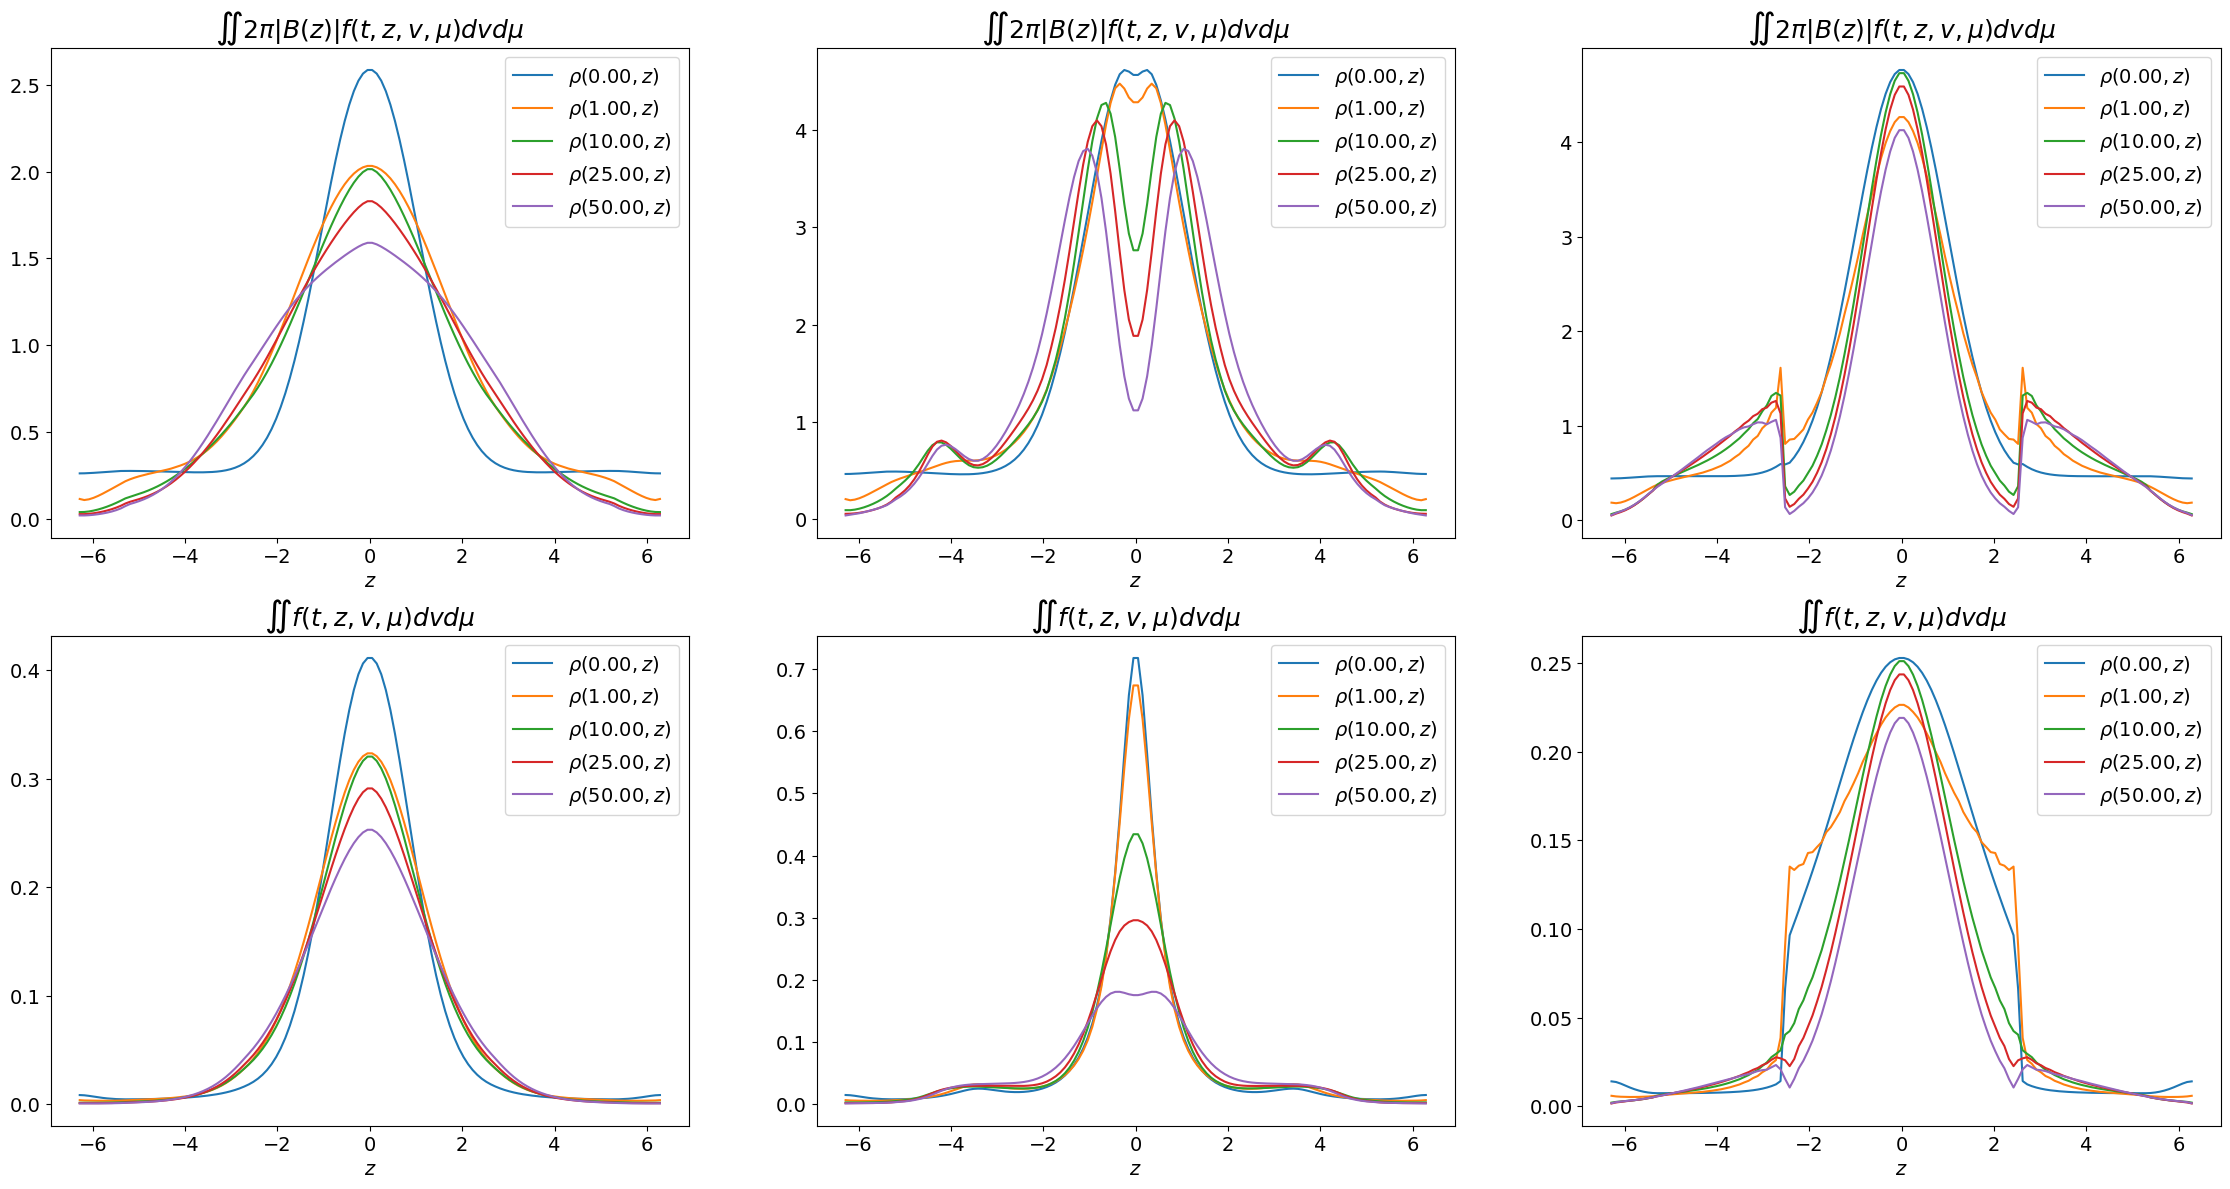

In [14]:
fig, axs = plt.subplots(2,3 ,figsize=(28, 14))

axs[0,0].plot(mesh.zs, 2*jnp.pi*B0_eval*rho_array_0[0,:], label='$\\rho({:.2f},z)$'.format(t_values[0]))
axs[0,0].plot(mesh.zs, 2*jnp.pi*B0_eval*rho_array_0[10,:], label='$\\rho({:.2f},z)$'.format(t_values[10]))
axs[0,0].plot(mesh.zs, 2*jnp.pi*B0_eval*rho_array_0[100,:], label='$\\rho({:.2f},z)$'.format(t_values[100]))
axs[0,0].plot(mesh.zs, 2*jnp.pi*B0_eval*rho_array_0[250,:], label='$\\rho({:.2f},z)$'.format(t_values[250]))
axs[0,0].plot(mesh.zs, 2*jnp.pi*B0_eval*rho_array_0[-1,:], label='$\\rho({:.2f},z)$'.format(t_values[-1]))
axs[0,0].set_title("$\\iint 2 \\pi |B(z)|f(t,z,v,\\mu)dvd\\mu$")
axs[0,0].set_xlabel("$z$")
#axs[0,0].set_yscale('log')
axs[0,0].legend()

axs[1,0].plot(mesh.zs, rho_array_0[0,:], label='$\\rho({:.2f},z)$'.format(t_values[0]))
axs[1,0].plot(mesh.zs, rho_array_0[10,:], label='$\\rho({:.2f},z)$'.format(t_values[10]))
axs[1,0].plot(mesh.zs, rho_array_0[100,:], label='$\\rho({:.2f},z)$'.format(t_values[100]))
axs[1,0].plot(mesh.zs, rho_array_0[250,:], label='$\\rho({:.2f},z)$'.format(t_values[250]))
axs[1,0].plot(mesh.zs, rho_array_0[-1,:], label='$\\rho({:.2f},z)$'.format(t_values[-1]))
axs[1,0].set_title("$\\iint f(t,z,v,\\mu)dvd\\mu$")
axs[1,0].set_xlabel("$z$")
#axs[1,0].set_yscale('log')
axs[1,0].legend()


axs[0,1].plot(mesh.zs, 2*jnp.pi*B1_eval*rho_array_1[0,:], label='$\\rho({:.2f},z)$'.format(t_values[0]))
axs[0,1].plot(mesh.zs, 2*jnp.pi*B1_eval*rho_array_1[10,:], label='$\\rho({:.2f},z)$'.format(t_values[10]))
axs[0,1].plot(mesh.zs, 2*jnp.pi*B1_eval*rho_array_1[100,:], label='$\\rho({:.2f},z)$'.format(t_values[100]))
axs[0,1].plot(mesh.zs, 2*jnp.pi*B1_eval*rho_array_1[250,:], label='$\\rho({:.2f},z)$'.format(t_values[250]))
axs[0,1].plot(mesh.zs, 2*jnp.pi*B1_eval*rho_array_1[-1,:], label='$\\rho({:.2f},z)$'.format(t_values[-1]))
axs[0,1].set_title("$\\iint 2 \\pi |B(z)|f(t,z,v,\\mu)dvd\\mu$")
axs[0,1].set_xlabel("$z$")
#axs[0,1].set_yscale('log')
axs[0,1].legend()

axs[1,1].plot(mesh.zs, rho_array_1[0,:], label='$\\rho({:.2f},z)$'.format(t_values[0]))
axs[1,1].plot(mesh.zs, rho_array_1[10,:], label='$\\rho({:.2f},z)$'.format(t_values[10]))
axs[1,1].plot(mesh.zs, rho_array_1[100,:], label='$\\rho({:.2f},z)$'.format(t_values[100]))
axs[1,1].plot(mesh.zs, rho_array_1[250,:], label='$\\rho({:.2f},z)$'.format(t_values[250]))
axs[1,1].plot(mesh.zs, rho_array_1[-1,:], label='$\\rho({:.2f},z)$'.format(t_values[-1]))
axs[1,1].set_title("$\\iint f(t,z,v,\\mu)dvd\\mu$")
axs[1,1].set_xlabel("$z$")
#axs[1,1].set_yscale('log')
axs[1,1].legend()


axs[0,2].plot(mesh.zs, 2*jnp.pi*B2_eval*rho_array_2[0,:], label='$\\rho({:.2f},z)$'.format(t_values[0]))
axs[0,2].plot(mesh.zs, 2*jnp.pi*B2_eval*rho_array_2[10,:], label='$\\rho({:.2f},z)$'.format(t_values[10]))
axs[0,2].plot(mesh.zs, 2*jnp.pi*B2_eval*rho_array_2[100,:], label='$\\rho({:.2f},z)$'.format(t_values[100]))
axs[0,2].plot(mesh.zs, 2*jnp.pi*B2_eval*rho_array_2[250,:], label='$\\rho({:.2f},z)$'.format(t_values[250]))
axs[0,2].plot(mesh.zs, 2*jnp.pi*B2_eval*rho_array_2[-1,:], label='$\\rho({:.2f},z)$'.format(t_values[-1]))
axs[0,2].set_title("$\\iint 2 \\pi |B(z)|f(t,z,v,\\mu)dvd\\mu$")
axs[0,2].set_xlabel("$z$")
#axs[0,2].set_yscale('log')
axs[0,2].legend()

axs[1,2].plot(mesh.zs, rho_array_2[0,:], label='$\\rho({:.2f},z)$'.format(t_values[0]))
axs[1,2].plot(mesh.zs, rho_array_2[10,:], label='$\\rho({:.2f},z)$'.format(t_values[10]))
axs[1,2].plot(mesh.zs, rho_array_2[100,:], label='$\\rho({:.2f},z)$'.format(t_values[100]))
axs[1,2].plot(mesh.zs, rho_array_2[250,:], label='$\\rho({:.2f},z)$'.format(t_values[250]))
axs[1,2].plot(mesh.zs, rho_array_2[-1,:], label='$\\rho({:.2f},z)$'.format(t_values[-1]))
axs[1,2].set_title("$\\iint f(t,z,v,\\mu)dvd\\mu$")
axs[1,2].set_xlabel("$z$")
#axs[1,2].set_yscale('log')
axs[1,2].legend()


plt.show()
#plt.savefig('Mirror/Plots/splines/rho.png', dpi=300, transparent=True, bbox_inches="tight")

In [15]:
@jax.jit
def cost_rho(rho_final):
    return jnp.sum(rho_final) * mesh.dz

vcost_rho = jax.vmap(cost_rho, in_axes=0, out_axes=0)
cost_rho_grad = jax.grad(vcost_rho)
#vcost_rho_grad = jax.vmap(cost_rho_grad, in_axes=(0,None), out_axes=0)

#@jax.jit
def cost_fn(params):

    
    B_, dB = build_B(B_min, B_max, z_min_0, 0.0, LZ,
                     B_b=B_b, z_0=0.0)
    B = B_(params, mesh.zs)
    dB = jax.vmap(dB, in_axes=(None,0))(params, mesh.zs)
    g = dB / B

    B_norm = B_(params, 0.0)
    
    f_eq = B_norm*jnp.exp(-0.5*((mesh.V)**2 + 2*B_norm*mesh.MU)) 
    f_iv = (0.1 + jnp.exp(-mesh.Z**2/(2*sigma_z**2))) * f_eq
    C = 1 / (jnp.sum((jnp.sum(f_iv, axis=(1,2))*mesh.dv*mesh.dmu))*mesh.dz)
    f_iv = C * f_iv

    f_array_1, f_total, E_array_1, ee_array_1, rho_array_1 = solver_jit(f_iv, B, dB, g, t_final=t_final)

    cost = cost_rho(rho_array_1[-1])

    return cost

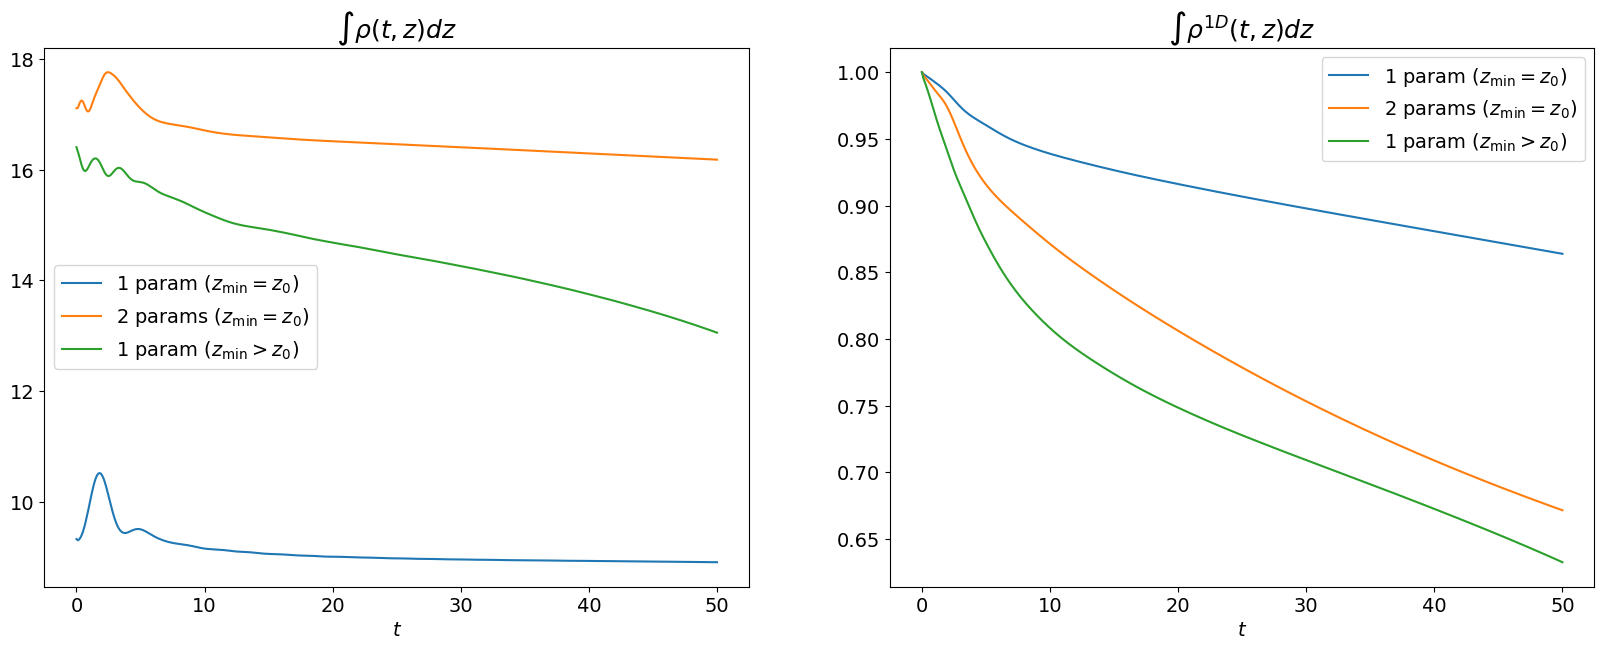

In [17]:
fig, axs = plt.subplots(1,2 ,figsize=(20, 7))

axs[0].plot(t_values, vcost_rho((2*jnp.pi*B0_eval*rho_array_0)), label='1 param ($z_\\min = z_0$)')
axs[0].plot(t_values, vcost_rho((2*jnp.pi*B1_eval*rho_array_1)), label='2 params ($z_\\min = z_0$)')
axs[0].plot(t_values, vcost_rho((2*jnp.pi*B2_eval*rho_array_2)), label='1 param ($z_\\min > z_0$)')
axs[0].set_xlabel('$t$')
axs[0].set_title("$\\int \\rho(t,z)dz$")
axs[0].legend()


axs[1].plot(t_values, vcost_rho(rho_array_0), label='1 param ($z_\\min = z_0$)')
axs[1].plot(t_values, vcost_rho(rho_array_1), label='2 params ($z_\\min = z_0$)')
axs[1].plot(t_values, vcost_rho(rho_array_2), label='1 param ($z_\\min > z_0$)')
axs[1].set_xlabel('$t$')
axs[1].set_title("$\\int \\rho^{1D}(t,z)dz$")
#axs[1].set_yscale('log')
axs[1].legend()


plt.show()
#plt.savefig('Mirror/Plots/splines/int_rho.png', dpi=300, transparent=True, bbox_inches="tight")

In [24]:
param = jnp.linspace(-1.0, 1.0, 100)

In [ ]:
#### 1D case ####

def body_1(carry, i):
    val = cost_fn(jnp.array([param[i]]))
    return carry.at[i].set(val), None


costs_1, _ = jax.lax.scan(
    body_1,
    jnp.zeros((100,)),
    jnp.arange(100)
)

In [ ]:
#### 2D case ####

def body_j_2(costs_i, j, i):
    val = cost_fn(jnp.array([param[i], param[j]]))
    return costs_i.at[j].set(val), None


def body_i_2(costs, i):
    row, _ = jax.lax.scan(
        lambda c, j: body_j_2(c, j, i),
        jnp.zeros((100,)),
        jnp.arange(100)
    )
    return costs.at[i].set(row), None


costs_2, _ = jax.lax.scan(
    body_i_2,
    jnp.zeros((100, 100)),
    jnp.arange(100)
)

In [ ]:
#### 3D case ####


def body_k_3(costs_ij, k, i, j):
    val = cost_fn(jnp.array([param[i], param[j], param[k]]))
    return costs_ij.at[k].set(val), None


def body_j_3(costs_i, j, i):
    vec, _ = jax.lax.scan(
        lambda c, k: body_k_3(c, k, i, j),
        jnp.zeros((100,)),
        jnp.arange(100)
    )
    return costs_i.at[j].set(vec), None


def body_i_3(costs, i):
    mat, _ = jax.lax.scan(
        lambda c, j: body_j_3(c, j, i),
        jnp.zeros((100, 100)),
        jnp.arange(100)
    )
    return costs.at[i].set(mat), None


costs_3, _ = jax.lax.scan(
    body_i_3,
    jnp.zeros((100, 100, 100)),
    jnp.arange(100)
)

In [ ]:
costs_1 = np.zeros((50,))
costs_2 = np.zeros((50,50))
costs_3 = np.zeros((50,50,50))


for i in range(50):
    costs_1[i] = cost_fn(jnp.array([param[i]]))
    for j in range(50):
        costs_2[i,j] = cost_fn(jnp.array([param[i], param[j]]))
        for k in range(50):
            costs_3[i,j,k] = cost_fn(jnp.array([param[i], param[j], param[k]]))

In [ ]:
#jnp.savez('Mirror/Costs/cost_splines_1_param.npz', cost=costs_1, params=param)
#jnp.savez('Mirror/Costs/cost_splines_2_param.npz', cost=costs_2, params=param)
jnp.savez('Mirror/Costs/cost_splines_3_param.npz', cost=costs_3, params=param)

In [75]:
file = jnp.load('Mirror/Costs/cost_splines_1_param.npz')
costs_1 = file['cost']
params = file['params']

file = jnp.load('Mirror/Costs/cost_splines_2_param.npz')
costs_2 = file['cost']

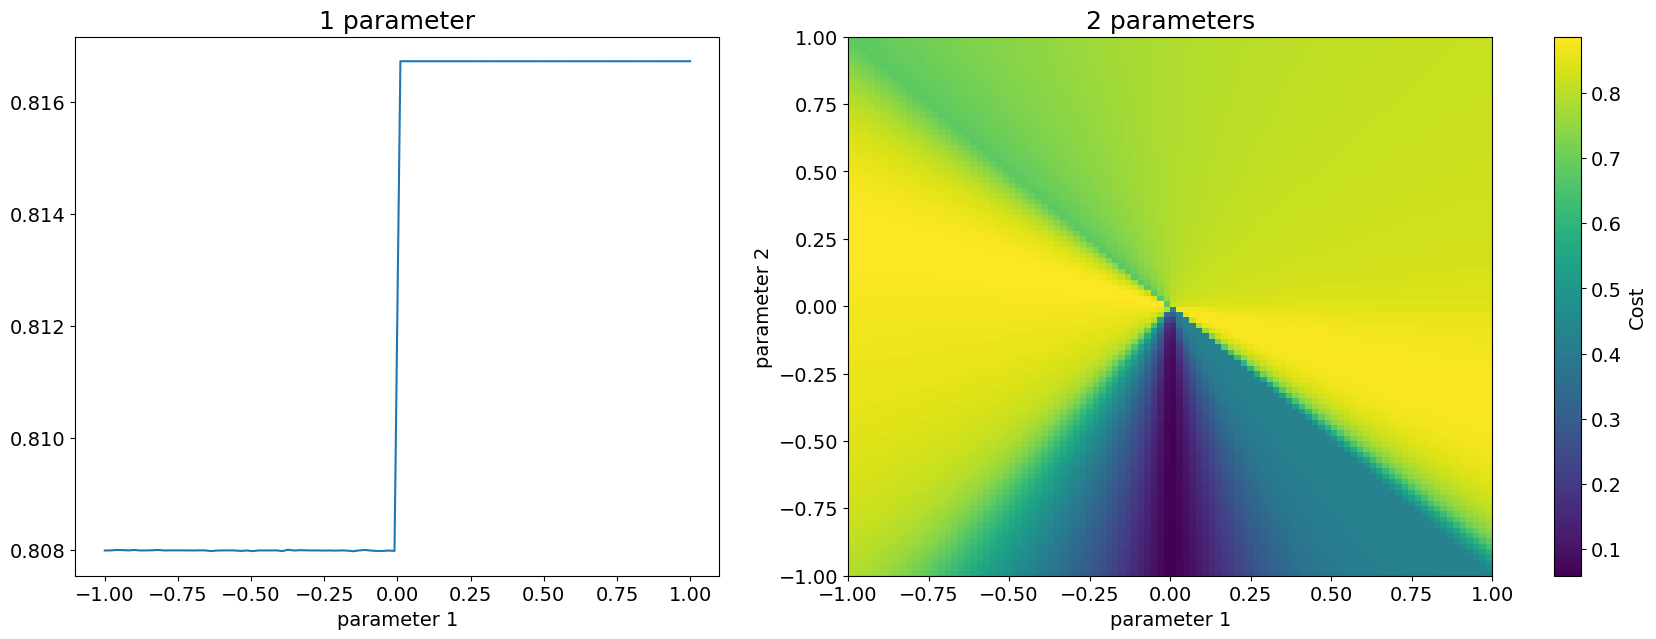

In [63]:
fig, axs = plt.subplots(1,2 ,figsize=(20, 7))

# Shared color scale
vmin = min(costs_1.min(), costs_2.min())
vmax = max(costs_1.max(), costs_2.max())

#im0 = axs[0].imshow(
#    costs_1,
#    origin='lower',
#    extent=[params[0], params[-1], params[0], params[-1]],
#    aspect='auto',
#    vmin=vmin,
#    vmax=vmax,
#)
axs[0].plot(params, costs_1)
axs[0].set_xlabel('parameter 1')
#axs[0].set_ylabel(r'$z_{2}$')
axs[0].set_title('1 parameter')

im1 = axs[1].imshow(
    costs_2,
    origin='lower',
    extent=[params[0], params[-1], params[0], params[-1]],
    aspect='auto',
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_xlabel('parameter 1')
axs[1].set_ylabel('parameter 2')
axs[1].set_title('2 parameters')

# Single shared colorbar
cbar = fig.colorbar(im1, ax=axs, fraction=0.046, pad=0.04)
cbar.set_label('Cost')

plt.show()
#plt.savefig('Mirror/Plots/splines/landscapes_1_2.png', dpi=300, transparent=True, bbox_inches="tight")

In [ ]:
fig, axs = plt.subplots(2,3 ,figsize=(28, 14))

axs[0,0].plot(mesh.zs, E_array_0[0,:] + mesh.mus[0]*dB0, label='$E({:.1f},z)$'.format(t_values[0]))
axs[0,0].plot(mesh.zs, E_array_0[10,:], label='$E({:.1f},z)$'.format(t_values[10]))
axs[0,0].plot(mesh.zs, E_array_0[25,:], label='$E({:.1f},z)$'.format(t_values[25]))
axs[0,0].plot(mesh.zs, E_array_0[50,:], label='$E({:.1f},z)$'.format(t_values[50]))
axs[0,0].set_title("$\\mathcal{E}_{f}(t)$")
#axs[0,0].set_yscale('log')
axs[0,0].set_xlabel("$t$")

axs[1,0].plot(mesh.zs, E_array_0[0,:] + mesh.mus[0]*dB0, label='$E({:.1f},z)$'.format(t_values[0]))
axs[1,0].plot(mesh.zs, E_array_0[10,:], label='$E({:.1f},z)$'.format(t_values[10]))
axs[1,0].plot(mesh.zs, E_array_0[25,:], label='$E({:.1f},z)$'.format(t_values[25]))
axs[1,0].plot(mesh.zs, E_array_0[50,:], label='$E({:.1f},z)$'.format(t_values[50]))
#axs[1,0].plot(mesh.zs, E_array_0[300,:], label='$E({:.1f},z)$'.format(t_values[300]))
#axs[1,0].plot(mesh.zs, E_array_0[400,:], label='$E({:.1f},z)$'.format(t_values[400]))
axs[1,0].plot(mesh.zs, E_array_0[-1,:], label='$E({:.1f},z)$'.format(t_values[-1]))
#axs[1,0].set_yscale('symlog')
axs[1,0].set_title("$E(t,z)$")
axs[1,0].set_xlabel("$z$")
axs[1,0].legend()


axs[0,1].plot(t_values[1:], ee_array_1)
axs[0,1].set_title("$\\mathcal{E}_{f}(t)$")
#axs[0,1].set_yscale('log')
axs[0,1].set_xlabel("$t$")

axs[1,1].plot(mesh.zs, E_array_1[0,:], label='$E({:.1f},z)$'.format(t_values[0]))
axs[1,1].plot(mesh.zs, E_array_1[10,:], label='$E({:.1f},z)$'.format(t_values[10]))
axs[1,1].plot(mesh.zs, E_array_1[25,:], label='$E({:.1f},z)$'.format(t_values[25]))
axs[1,1].plot(mesh.zs, E_array_1[50,:], label='$E({:.1f},z)$'.format(t_values[50]))
#axs[1,1].plot(mesh.zs, E_array_1[300,:], label='$E({:.1f},z)$'.format(t_values[300]))
#axs[1,1].plot(mesh.zs, E_array_1[400,:], label='$E({:.1f},z)$'.format(t_values[400]))
axs[1,1].plot(mesh.zs, E_array_1[-1,:], label='$E({:.1f},z)$'.format(t_values[-1]))
#axs[1,1].set_yscale('symlog')
axs[1,1].set_title("$E(t,z)$")
axs[1,1].set_xlabel("$z$")
axs[1,1].legend()




axs[0,2].plot(t_values[1:], ee_array_2)
axs[0,2].set_title("$\\mathcal{E}_{f}(t)$")
#axs[0,2].set_yscale('log')
axs[0,2].set_xlabel("$t$")

axs[1,2].plot(mesh.zs, E_array_2[0,:], label='$E({:.1f},z)$'.format(t_values[0]))
axs[1,2].plot(mesh.zs, E_array_2[10,:], label='$E({:.1f},z)$'.format(t_values[10]))
axs[1,2].plot(mesh.zs, E_array_2[25,:], label='$E({:.1f},z)$'.format(t_values[25]))
axs[1,2].plot(mesh.zs, E_array_2[50,:], label='$E({:.1f},z)$'.format(t_values[50]))
#axs[1,2].plot(mesh.zs, E_array_2[300,:], label='$E({:.1f},z)$'.format(t_values[300]))
#axs[1,2].plot(mesh.zs, E_array_2[400,:], label='$E({:.1f},z)$'.format(t_values[400]))
axs[1,2].plot(mesh.zs, E_array_2[-1,:], label='$E({:.1f},z)$'.format(t_values[-1]))
#axs[1,2].set_yscale('symlog')
axs[1,2].set_title("$E(t,z)$")
axs[1,2].set_xlabel("$z$")
axs[1,2].legend()



plt.show()

In [76]:
print(costs_1)

[0.8079927  0.8079935  0.8080023  0.8079997  0.8079937  0.80800176
 0.8079927  0.80799353 0.807996   0.80800223 0.80799335 0.80799437
 0.8079945  0.80799514 0.8079938  0.80799323 0.8079946  0.8079943
 0.8079823  0.80799186 0.80799353 0.80799466 0.8079929  0.8079843
 0.8079925  0.80798125 0.807993   0.8079937  0.807993   0.8079943
 0.8079817  0.80800533 0.8079925  0.8079977  0.80799526 0.80799323
 0.8079937  0.8079908  0.80799323 0.8079901  0.80799395 0.8079906
 0.8079794  0.80799353 0.80800253 0.80799127 0.80798364 0.8079845
 0.80799156 0.8079849  0.8167283  0.81672853 0.8167284  0.8167281
 0.8167281  0.8167281  0.8167283  0.8167281  0.81672823 0.8167281
 0.8167281  0.81672823 0.81672794 0.81672794 0.81672823 0.81672794
 0.81672806 0.81672823 0.8167283  0.8167283  0.8167281  0.8167281
 0.8167283  0.81672806 0.8167281  0.8167283  0.8167281  0.81672794
 0.81672794 0.8167283  0.8167283  0.81672806 0.8167281  0.8167283
 0.81672794 0.8167281  0.8167283  0.8167283  0.8167281  0.81672794
 0.8